# 📊 Comparativa de Modelos Embeddings para Traducción Multilingüe

**Título del Trabajo:** Cl@udiata: Modelos de Lenguaje en la Analítica Deportiva  
**Nombre del Estudiante:** Pedro José García Fernández  
**Tutor/a de TF:** Arturo González Martínez  
**Profesor/a responsable:** Susana Acedo  
**Fecha:** 27 Diciembre 2024  
**Titulación o programa:** Grado de Ciencia de Datos Aplicada  
**Área de trabajo:** Trabajo Final de Grado  
**Idioma:** Castellano  
**Palabras Clave:** Embeddings Multilingües - RAG - Sentence-Transformers - Edge Computing - Jetson AGX Orin - Luxemburgués

---

**Épica:** DWH - Transformación y Almacenamiento Semántico  
**Tarea:** DWH-20: Generación de Embeddings Multilingües para Capa Oro  
**Sprint:** M1 (Diciembre 2024 - Semanas 3-4)  
**Asignatura UOC:** Trabajo Final de Grado

---

## 🎯 Objetivo del Experimento

Seleccionar el **modelo de embeddings óptimo** para el sistema RAG del agente Cl@udiata en hardware edge (Jetson AGX Orin 64GB), mediante evaluación empírica de calidad semántica multilingüe, eficiencia computacional y viabilidad operacional.

**Enfoque:** Priorizar capacidad cross-language luxemburgués→inglés como métrica crítica.

## Contexto

Tras implementar en **DWH-10** el pipeline de traducción luxemburgués→español con LLMs (Qwen2.5:32b), este experimento evalúa qué modelo de embeddings maximiza la precisión de búsqueda semántica cross-language.

**Reto técnico:** Luxemburgués es un idioma germánico de bajos recursos (~600K hablantes). Se requiere un modelo multilingüe robusto sin fine-tuning específico.

## Hipótesis

**multilingual-E5-large** ofrece el mejor balance calidad-eficiencia para embeddings cross-language en idiomas de bajos recursos, superando a modelos especializados en inglés (nomic-embed-text) y alternativas ligeras (MiniLM-L12-v2) en similitud luxemburgués↔inglés, con overhead <100ms/embedding en Jetson AGX Orin.

---

## 📊 Criterios de Evaluación (Ponderados)

| Criterio | Peso | Métrica | Umbral Mínimo |
|----------|------|---------|---------------|
| **Similitud LB↔EN** | 60% | Cosine similarity | >0.80 |
| **Capacidad Multilingüe** | 20% | Similitud promedio otros pares | >0.75 |
| **Calidad Búsqueda** | 10% | Precisión@1 en queries | >0.70 |
| **Eficiencia Computacional** | 5% | Latencia embedding | <150ms |
| **Viabilidad Hardware** | 5% | Memoria GPU requerida | <4GB |

### Justificación de pesos

- **Similitud LB↔EN (60%):** Prioridad absoluta - determina calidad del RAG
- **Capacidad Multilingüe (20%):** Validación robustez (FR, DE, ES, PT)
- **Calidad Búsqueda (10%):** Métrica funcional directa
- **Eficiencia Computacional (5%):** Procesamiento batch offline
- **Viabilidad Hardware (5%):** 64GB RAM disponibles

---

## 🔬 Metodología

### 1. Corpus de Prueba
- **Textos luxemburgués:** 3 eventos deportivos reales
- **Traducciones:** ES, EN, FR, DE, PT (Qwen2.5:32b)
- **Queries:** 5 por idioma

### 2. Modelos Evaluados (9 total)
- **Sentence-Transformers:** 7 modelos
- **Ollama:** 2 modelos

### 3. Infraestructura
- **Hardware:** Jetson AGX Orin 64GB (2048 CUDA cores)
- **Software:** PyTorch 2.0 + CUDA 12.6
- **Monitoreo:** tegrastats

### 4. Métricas
- Similitud coseno (15 pares)
- Latencia, GPU usage, memoria CUDA
- Consumo energético, temperaturas

---

## 🧪 Metodología del Experimento

### Modelos de Embeddings Evaluados

**Sentence-Transformers (7 modelos)**

| Modelo | Dimensiones | Tamaño | Especialización |
|--------|-------------|--------|-----------------|
| **multilingual-E5-large** | 1024 | 2.2 GB | SOTA multilingüe (100+ idiomas) |
| **LaBSE** | 768 | 1.8 GB | Google - 109 idiomas |
| **bge-m3** | 1024 | 2.2 GB | BAAI - 100 idiomas |
| **multilingual-MiniLM-L12-v2** | 384 | 470 MB | Baseline ligero |
| **multilingual-mpnet** | 768 | 1.1 GB | Alta calidad paráfrasis |
| **distiluse-v1** | 512 | 500 MB | Rápido y eficiente |
| **stella-large** | 1792 | 3.5 GB | Alta dimensión |

**Ollama (2 modelos)**

| Modelo | Dimensiones | Tamaño | Especialización |
|--------|-------------|--------|-----------------|
| **nomic-embed-text** | 768 | 308 MB | Optimizado inglés |
| **mxbai-embed-large** | 1024 | 718 MB | MixedBread AI |

### Corpus de Evaluación

**Textos de prueba:** 3 eventos deportivos × 6 idiomas (LB, ES, EN, FR, DE, PT)

**Fuente:** Comentarios reales de fútbol luxemburgués traducidos con Qwen2.5:32b

**Queries de búsqueda:** 5 por idioma (simulando consultas RAG reales)

### Métricas Registradas

**Calidad Semántica:**
- Similitud coseno cross-language (15 pares de idiomas)
- Precisión@1 en búsqueda semántica

**Rendimiento:**
- Latencia por embedding (ms)
- Uso GPU (%)
- Memoria CUDA allocated (GB)

**Hardware:**
- Consumo energético GPU (W)
- Temperaturas SOC/CPU (°C)

### Configuración Técnica

- **Hardware:** NVIDIA Jetson AGX Orin 64GB (2048 CUDA cores, Ampere)
- **JetPack:** 6.2.1 (CUDA 12.6, PyTorch 2.0)
- **Entorno Python:** Conda `uoc` (Python 3.10)
- **Monitoreo:** tegrastats (intervalo 500ms)
- **Runs por modelo:** 3 iteraciones para estabilidad

## MEMORIA

In [2]:
import getpass
import os

# Guardar password para comandos sudo
SUDO_PASSWORD = getpass.getpass("Contraseña sudo: ")

# Usar en comandos
def sudo_run(cmd):
    full_cmd = f"echo {SUDO_PASSWORD} | sudo -S {cmd}"
    return subprocess.run(full_cmd, shell=True, capture_output=True, text=True)

Contraseña sudo:  ········


In [3]:
# ============================================================================
# FUNCIONES DE MONITOREO OPTIMIZADAS PARA JETSON (con tegrastats)
# ============================================================================

import subprocess
import gc
import torch
import re
from datetime import datetime

def ver_memoria_jetson():
    """
    Muestra estado de memoria RAM y GPU usando tegrastats (Jetson-optimizado)
    """
    print("=" * 80)
    print("💾 ESTADO DE MEMORIA (Jetson AGX Orin)")
    print("=" * 80)
    
    # Memoria RAM con free
    print("\n🧠 RAM (free -h):")
    print("-" * 80)
    result = subprocess.run(['free', '-h'], capture_output=True, text=True)
    print(result.stdout)
    
    # Tegrastats (snapshot único)
    print("\n🎮 GPU + SOC (tegrastats):")
    print("-" * 80)
    
    try:
        # Ejecutar tegrastats por 1 segundo
        result = subprocess.run(['tegrastats', '--interval', '500'], 
                               capture_output=True, text=True, timeout=2)
        
        lines = result.stdout.strip().split('\n')
        if lines:
            ultima_linea = lines[-1]  # Última medición
            
            # Parsear tegrastats (formato Jetson AGX Orin)
            print(f"Timestamp: {datetime.now().strftime('%H:%M:%S')}\n")
            
            # RAM
            ram_match = re.search(r'RAM (\d+)/(\d+)MB', ultima_linea)
            if ram_match:
                ram_used = int(ram_match.group(1))
                ram_total = int(ram_match.group(2))
                ram_percent = (ram_used / ram_total) * 100
                print(f"📊 RAM Sistema:")
                print(f"   Usado: {ram_used}MB / {ram_total}MB ({ram_percent:.1f}%)")
                print(f"   Disponible: {ram_total - ram_used}MB")
            
            # GPU
            gpu_match = re.search(r'GR3D_FREQ\s+(\d+)%', ultima_linea)
            if gpu_match:
                gpu_util = int(gpu_match.group(1))
                print(f"\n🎮 GPU (GR3D):")
                print(f"   Uso: {gpu_util}%")
            
            # CPU
            cpu_matches = re.findall(r'CPU\s+\[([^\]]+)\]', ultima_linea)
            if cpu_matches:
                cpu_values = re.findall(r'(\d+)%', cpu_matches[0])
                if cpu_values:
                    cpu_avg = sum(int(v) for v in cpu_values) / len(cpu_values)
                    print(f"\n💻 CPU:")
                    print(f"   Uso promedio: {cpu_avg:.1f}%")
                    print(f"   Cores: {', '.join(cpu_values)}%")
            
            # Potencia
            power_match = re.search(r'VDD_GPU_SOC\s+(\d+)mW', ultima_linea)
            if power_match:
                power_mw = int(power_match.group(1))
                print(f"\n⚡ Potencia GPU:")
                print(f"   Consumo: {power_mw}mW ({power_mw/1000:.2f}W)")
            
            # Temperaturas
            print(f"\n🌡️  Temperaturas:")
            
            # CPU/Junction
            temp_tj = re.search(r'tj@([\d.]+)C', ultima_linea)
            if temp_tj:
                print(f"   CPU/Junction: {temp_tj.group(1)}°C")
            
            # SOC
            temp_socs = re.findall(r'soc\d@([\d.]+)C', ultima_linea)
            if temp_socs:
                soc_avg = sum(float(t) for t in temp_socs) / len(temp_socs)
                print(f"   SOC promedio: {soc_avg:.1f}°C")
    
    except subprocess.TimeoutExpired:
        print("⚠️  tegrastats timeout (normal)")
    except Exception as e:
        print(f"⚠️  Error ejecutando tegrastats: {e}")
        print("   Asegúrate de tener permisos: sudo usermod -aG video $USER")
    
    # CUDA Memory desde PyTorch
    if torch.cuda.is_available():
        print("\n🔥 CUDA Memory (PyTorch):")
        print("-" * 80)
        
        for i in range(torch.cuda.device_count()):
            allocated = torch.cuda.memory_allocated(i) / 1e9
            reserved = torch.cuda.memory_reserved(i) / 1e9
            total = torch.cuda.get_device_properties(i).total_memory / 1e9
            free = total - reserved
            
            print(f"GPU {i} ({torch.cuda.get_device_name(i)}):")
            print(f"   Allocated: {allocated:.2f} GB ({allocated/total*100:.1f}%)")
            print(f"   Reserved:  {reserved:.2f} GB ({reserved/total*100:.1f}%)")
            print(f"   Total:     {total:.2f} GB")
            print(f"   Free:      {free:.2f} GB ({free/total*100:.1f}%)")
            
            # Advertencia si poca memoria
            if free < 5:
                print(f"   ⚠️  ADVERTENCIA: Solo {free:.1f}GB libres!")
            print()
    
    print("=" * 80)


def ver_procesos_jetson():
    """
    Muestra procesos y uso de recursos en Jetson
    """
    print("=" * 80)
    print("🔍 PROCESOS Y RECURSOS (Jetson)")
    print("=" * 80)
    
    # Procesos Python/Ollama
    print("\n🐍 Procesos Python/Ollama:")
    print("-" * 80)
    result = subprocess.run(['ps', 'aux'], capture_output=True, text=True)
    
    found = False
    for line in result.stdout.split('\n'):
        if ('python' in line.lower() or 'ollama' in line.lower()) and 'ps aux' not in line:
            found = True
            # Extraer info relevante
            parts = line.split()
            if len(parts) >= 11:
                user = parts[0]
                pid = parts[1]
                cpu = parts[2]
                mem = parts[3]
                cmd = ' '.join(parts[10:])[:80]
                print(f"PID {pid:>6} | CPU {cpu:>5}% | MEM {mem:>5}% | {cmd}")
    
    if not found:
        print("   Sin procesos Python/Ollama activos")
    
    # Top consumidores de memoria
    print("\n🧠 Top 5 Consumidores de Memoria:")
    print("-" * 80)
    result = subprocess.run(['ps', 'aux', '--sort=-rss'], 
                           capture_output=True, text=True)
    lines = result.stdout.split('\n')[1:6]  # Top 5
    for line in lines:
        if line.strip():
            parts = line.split()
            if len(parts) >= 11:
                cmd = ' '.join(parts[10:])[:60]
                mem_mb = int(parts[5]) / 1024  # RSS en KB -> MB
                print(f"   {mem_mb:>8.1f}MB | {parts[3]:>5}% | {cmd}")
    
    print("=" * 80)


def limpiar_memoria_jetson():
    """
    Limpieza optimizada para Jetson
    """
    print("=" * 80)
    print("🧹 LIMPIANDO MEMORIA (Jetson)")
    print("=" * 80)
    
    # 1. Estado inicial
    print("\n📊 Estado inicial:")
    if torch.cuda.is_available():
        mem_before = torch.cuda.memory_allocated(0) / 1e9
        reserved_before = torch.cuda.memory_reserved(0) / 1e9
        print(f"   CUDA Allocated: {mem_before:.2f}GB")
        print(f"   CUDA Reserved:  {reserved_before:.2f}GB")
    
    # 2. Python GC
    print("\n1️⃣ Garbage collector...")
    collected = gc.collect()
    print(f"   ✅ {collected} objetos liberados")
    
    # 3. CUDA cache
    if torch.cuda.is_available():
        print("\n2️⃣ Limpiando CUDA cache...")
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print("   ✅ Cache limpiado")
    
    # 4. Limpiar cache del sistema (opcional)
    print("\n3️⃣ Limpiando cache del sistema...")
    try:
        # sync + drop_caches (requiere sudo)
        subprocess.run(['sync'], check=True)
        # Solo intentar si tenemos permisos
        result = subprocess.run(['sudo', '-n', 'sh', '-c', 
                                'echo 1 > /proc/sys/vm/drop_caches'],
                               capture_output=True, text=True)
        if result.returncode == 0:
            print("   ✅ System cache limpiado")
        else:
            print("   ⚠️  System cache no limpiado (requiere sudo)")
    except:
        print("   ⚠️  System cache no limpiado")
    
    # 5. GC final
    gc.collect()
    
    # 6. Estado final
    print("\n📊 Estado final:")
    if torch.cuda.is_available():
        mem_after = torch.cuda.memory_allocated(0) / 1e9
        reserved_after = torch.cuda.memory_reserved(0) / 1e9
        print(f"   CUDA Allocated: {mem_after:.2f}GB (Δ {mem_before-mem_after:.2f}GB)")
        print(f"   CUDA Reserved:  {reserved_after:.2f}GB (Δ {reserved_before-reserved_after:.2f}GB)")
    
    print("\n✅ Limpieza completada")
    print("=" * 80)


def diagnostico_completo_jetson():
    """
    Diagnóstico completo del sistema Jetson
    """
    print("=" * 80)
    print("🔬 DIAGNÓSTICO COMPLETO JETSON AGX ORIN")
    print("=" * 80)
    
    # 1. Memoria
    ver_memoria_jetson()
    
    # 2. Procesos
    print("\n")
    ver_procesos_jetson()
    
    # 3. Estado Ollama
    print("\n" + "=" * 80)
    print("🤖 OLLAMA STATUS")
    print("=" * 80)
    
    try:
        from ollama import Client
        client = Client(host="http://192.168.1.22:11434")
        response = client.list()
        print(f"\n✅ Ollama activo - {len(response.models)} modelos disponibles:")
        for model in response.models:
            print(f"   - {model.model}")
    except Exception as e:
        print(f"\n❌ Ollama ERROR: {e}")
    
    print("\n" + "=" * 80)


# Alias cortos
ver_memoria = ver_memoria_jetson
ver_procesos = ver_procesos_jetson
limpiar_memoria = limpiar_memoria_jetson
diagnostico = diagnostico_completo_jetson

print("✅ Funciones Jetson cargadas:")
print("   - ver_memoria()          # Ver RAM + GPU + Temperaturas")
print("   - ver_procesos()         # Ver procesos activos")
print("   - limpiar_memoria()      # Limpiar CUDA + GC")
print("   - diagnostico()          # Diagnóstico completo")

# ============================================================================
# REINICIAR OLLAMA COMPLETAMENTE
# ============================================================================

import subprocess
import time

def reiniciar_ollama(esperar_segundos=10):
    """
    Mata todos los procesos Ollama y reinicia el servicio
    
    Args:
        esperar_segundos: Tiempo de espera después de reiniciar (default: 10)
    """
    print("=" * 80)
    print("🔄 REINICIANDO OLLAMA COMPLETAMENTE")
    print("=" * 80)
    
    # 1. Detener servicio systemd
    print("\n1️⃣ Deteniendo servicio Ollama...")
    result = subprocess.run(['sudo', 'systemctl', 'stop', 'ollama'], 
                           capture_output=True, text=True)
    if result.returncode == 0:
        print("   ✅ Servicio detenido")
    else:
        print(f"   ⚠️  {result.stderr}")
    
    time.sleep(2)
    
    # 2. Matar TODOS los procesos ollama (por si acaso)
    print("\n2️⃣ Matando procesos ollama residuales...")
    subprocess.run(['sudo', 'pkill', '-9', '-f', 'ollama'], 
                  capture_output=True)
    print("   ✅ Procesos eliminados")
    
    time.sleep(2)
    
    # 3. Limpiar GPU
    print("\n3️⃣ Limpiando CUDA cache...")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print("   ✅ CUDA limpio")
    
    # 4. Verificar que no hay procesos
    print("\n4️⃣ Verificando limpieza...")
    result = subprocess.run(['ps', 'aux'], capture_output=True, text=True)
    if 'ollama' in result.stdout.lower():
        print("   ⚠️  Aún hay procesos ollama")
        # Fuerza bruta
        subprocess.run(['sudo', 'killall', '-9', 'ollama'], capture_output=True)
    else:
        print("   ✅ Sin procesos ollama")
    
    time.sleep(2)
    
    # 5. Reiniciar servicio
    print("\n5️⃣ Reiniciando servicio Ollama...")
    result = subprocess.run(['sudo', 'systemctl', 'start', 'ollama'], 
                           capture_output=True, text=True)
    if result.returncode == 0:
        print("   ✅ Servicio iniciado")
    else:
        print(f"   ❌ Error: {result.stderr}")
        return False
    
    # 6. Esperar que esté listo
    print(f"\n6️⃣ Esperando {esperar_segundos}s que Ollama esté listo...")
    time.sleep(esperar_segundos)
    
    # 7. Verificar estado
    print("\n7️⃣ Verificando estado del servicio...")
    result = subprocess.run(['sudo', 'systemctl', 'status', 'ollama'], 
                           capture_output=True, text=True)
    if 'active (running)' in result.stdout:
        print("   ✅ Servicio activo")
    else:
        print("   ⚠️  Servicio no activo")
        print(result.stdout[:500])
    
    # 8. Test de conexión
    print("\n8️⃣ Probando conexión...")
    try:
        from ollama import Client
        client = Client(host="http://192.168.1.22:11434")
        response = client.list()
        print(f"   ✅ Ollama respondiendo - {len(response.models)} modelos")
    except Exception as e:
        print(f"   ❌ Error de conexión: {e}")
        return False
    
    print("\n" + "=" * 80)
    print("✅ OLLAMA REINICIADO CORRECTAMENTE")
    print("=" * 80)
    
    return True


def estado_ollama():
    """Muestra estado actual del servicio Ollama"""
    print("=" * 80)
    print("📊 ESTADO OLLAMA")
    print("=" * 80)
    
    # Estado systemd
    print("\n🔧 Servicio systemd:")
    result = subprocess.run(['sudo', 'systemctl', 'status', 'ollama'], 
                           capture_output=True, text=True)
    
    if 'active (running)' in result.stdout:
        print("   ✅ Activo")
    elif 'inactive' in result.stdout:
        print("   ⏸️  Inactivo")
    else:
        print("   ❌ Error")
    
    # Procesos
    print("\n🔍 Procesos ollama:")
    result = subprocess.run(['ps', 'aux'], capture_output=True, text=True)
    ollama_procs = [line for line in result.stdout.split('\n') if 'ollama' in line.lower()]
    
    if ollama_procs:
        for proc in ollama_procs:
            print(f"   {proc}")
    else:
        print("   Sin procesos")
    
    # Conexión
    print("\n🌐 Conexión API:")
    try:
        from ollama import Client
        client = Client(host="http://192.168.1.22:11434")
        response = client.list()
        print(f"   ✅ Conectado - {len(response.models)} modelos")
    except Exception as e:
        print(f"   ❌ Error: {e}")
    
    print("=" * 80)


print("✅ Funciones de Ollama cargadas:")
print("   - reiniciar_ollama()")
print("   - estado_ollama()")

# ============================================================================
# GESTIÓN DE PROCESOS JUPYTER
# ============================================================================

import subprocess
import psutil
import os
import torch
from datetime import datetime

def ver_jupyter_procesos():
    """
    Muestra todos los procesos Jupyter activos
    """
    print("=" * 80)
    print("📓 PROCESOS JUPYTER")
    print("=" * 80)
    
    # PID del notebook actual
    pid_actual = os.getpid()
    print(f"\n🎯 Notebook actual: PID {pid_actual}")
    print("-" * 80)
    
    # Buscar todos los procesos Jupyter
    procesos_jupyter = []
    
    for proc in psutil.process_iter(['pid', 'name', 'cmdline', 'memory_info', 'cpu_percent']):
        try:
            cmdline = ' '.join(proc.info['cmdline']) if proc.info['cmdline'] else ''
            
            # Filtrar procesos Jupyter
            if any(x in cmdline.lower() for x in ['jupyter', 'ipython', 'ipykernel']):
                procesos_jupyter.append({
                    'pid': proc.info['pid'],
                    'name': proc.info['name'],
                    'cmdline': cmdline[:100],  # Truncar
                    'memoria_mb': proc.info['memory_info'].rss / 1024 / 1024,
                    'cpu': proc.info['cpu_percent']
                })
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            continue
    
    # Mostrar resultados
    print(f"\n📋 Procesos Jupyter encontrados: {len(procesos_jupyter)}\n")
    
    if not procesos_jupyter:
        print("   Sin procesos Jupyter activos")
        return
    
    # Agrupar por tipo
    servers = []
    kernels = []
    otros = []
    
    for p in procesos_jupyter:
        if 'jupyter-lab' in p['cmdline'] or 'jupyter-notebook' in p['cmdline']:
            servers.append(p)
        elif 'ipykernel' in p['cmdline']:
            kernels.append(p)
        else:
            otros.append(p)
    
    # Mostrar servidores
    if servers:
        print("🖥️  SERVIDORES JUPYTER:")
        print("-" * 80)
        for p in servers:
            actual = " ← ACTUAL" if p['pid'] == pid_actual else ""
            print(f"PID {p['pid']:>6} | RAM {p['memoria_mb']:>8.1f}MB | CPU {p['cpu']:>5.1f}% {actual}")
            print(f"         {p['cmdline'][:80]}")
            print()
    
    # Mostrar kernels
    if kernels:
        print("🔬 KERNELS JUPYTER:")
        print("-" * 80)
        for p in kernels:
            actual = " ← ACTUAL" if p['pid'] == pid_actual else ""
            print(f"PID {p['pid']:>6} | RAM {p['memoria_mb']:>8.1f}MB | CPU {p['cpu']:>5.1f}% {actual}")
            print(f"         {p['cmdline'][:80]}")
            print()
    
    # Mostrar otros
    if otros:
        print("📦 OTROS PROCESOS:")
        print("-" * 80)
        for p in otros:
            print(f"PID {p['pid']:>6} | RAM {p['memoria_mb']:>8.1f}MB | {p['name']}")
    
    # Resumen
    total_ram = sum(p['memoria_mb'] for p in procesos_jupyter)
    print("-" * 80)
    print(f"TOTAL: {len(procesos_jupyter)} procesos | RAM: {total_ram:.1f}MB")
    print("=" * 80)


def matar_jupyter_proceso(pid):
    """
    Mata un proceso Jupyter específico
    
    Args:
        pid: PID del proceso a matar
    """
    pid_actual = os.getpid()
    
    if pid == pid_actual:
        print("⚠️  NO puedes matar el notebook actual desde el mismo notebook")
        print("   Usa 'Kernel → Shutdown' o cierra la pestaña del navegador")
        return False
    
    try:
        proc = psutil.Process(pid)
        nombre = proc.name()
        
        print(f"🔪 Matando proceso {pid} ({nombre})...")
        proc.terminate()
        
        # Esperar hasta 5 segundos
        proc.wait(timeout=5)
        print(f"✅ Proceso {pid} terminado")
        return True
        
    except psutil.NoSuchProcess:
        print(f"❌ Proceso {pid} no existe")
        return False
    except psutil.TimeoutExpired:
        print(f"⚠️  Proceso {pid} no responde, forzando...")
        proc.kill()
        print(f"✅ Proceso {pid} forzado a terminar")
        return True
    except Exception as e:
        print(f"❌ Error: {e}")
        return False


def matar_kernels_inactivos():
    """
    Mata todos los kernels Jupyter excepto el actual
    """
    print("=" * 80)
    print("🧹 LIMPIANDO KERNELS INACTIVOS")
    print("=" * 80)
    
    pid_actual = os.getpid()
    kernels_matados = 0
    
    for proc in psutil.process_iter(['pid', 'cmdline']):
        try:
            cmdline = ' '.join(proc.info['cmdline']) if proc.info['cmdline'] else ''
            
            if 'ipykernel' in cmdline and proc.info['pid'] != pid_actual:
                print(f"\n🔪 Matando kernel PID {proc.info['pid']}...")
                proc.terminate()
                kernels_matados += 1
                
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            continue
    
    if kernels_matados > 0:
        print(f"\n✅ {kernels_matados} kernels terminados")
    else:
        print("\n✅ No hay kernels inactivos")
    
    print("=" * 80)


def info_jupyter_actual():
    """
    Muestra información del notebook actual
    """
    print("=" * 80)
    print("📓 INFORMACIÓN NOTEBOOK ACTUAL")
    print("=" * 80)
    
    pid = os.getpid()
    proc = psutil.Process(pid)
    
    # Info básica
    create_time = datetime.fromtimestamp(proc.create_time())
    print(f"\n🎯 PID: {pid}")
    print(f"📛 Nombre: {proc.name()}")
    print(f"🕐 Iniciado: {create_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Recursos
    mem_info = proc.memory_info()
    print(f"\n💾 Memoria:")
    print(f"   RSS: {mem_info.rss / 1024 / 1024:.1f} MB")
    print(f"   VMS: {mem_info.vms / 1024 / 1024:.1f} MB")
    
    cpu_percent = proc.cpu_percent(interval=1)
    print(f"\n💻 CPU:")
    print(f"   Uso: {cpu_percent:.1f}%")
    
    # CUDA (si aplica)
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1e9
        print(f"\n🎮 CUDA:")
        print(f"   Allocated: {allocated:.2f} GB")
    
    # Conexiones (CORREGIDO - usar net_connections)
    try:
        # Usar net_connections() en vez de connections()
        conexiones = [c for c in psutil.net_connections() if c.pid == pid]
        print(f"\n🌐 Conexiones activas: {len(conexiones)}")
        
        # Mostrar algunas conexiones importantes
        if conexiones and len(conexiones) > 0:
            print("   Top conexiones:")
            for conn in conexiones[:3]:
                estado = conn.status
                laddr = f"{conn.laddr.ip}:{conn.laddr.port}" if conn.laddr else "N/A"
                print(f"   - {estado:12s} {laddr}")
    except (psutil.AccessDenied, AttributeError):
        print(f"\n🌐 Conexiones: (no disponible sin permisos)")
    
    # Hilos
    try:
        num_threads = proc.num_threads()
        print(f"\n🧵 Hilos: {num_threads}")
    except:
        pass
    
    print("=" * 80)


def jupyter_stats():
    """
    Estadísticas rápidas de Jupyter
    """
    pid_actual = os.getpid()
    proc_actual = psutil.Process(pid_actual)
    
    # Contar procesos
    total_jupyter = 0
    total_kernels = 0
    total_ram = 0
    
    for proc in psutil.process_iter(['pid', 'cmdline', 'memory_info']):
        try:
            cmdline = ' '.join(proc.info['cmdline']) if proc.info['cmdline'] else ''
            if any(x in cmdline.lower() for x in ['jupyter', 'ipykernel']):
                total_jupyter += 1
                total_ram += proc.info['memory_info'].rss / 1024 / 1024
                if 'ipykernel' in cmdline:
                    total_kernels += 1
        except:
            continue
    
    # Mostrar compacto
    mem_actual = proc_actual.memory_info().rss / 1024 / 1024
    cpu_actual = proc_actual.cpu_percent(interval=0.5)
    
    print(f"📊 Jupyter: {total_jupyter} procesos | {total_kernels} kernels | {total_ram:.0f}MB RAM total")
    print(f"🎯 Actual: PID {pid_actual} | {mem_actual:.0f}MB | CPU {cpu_actual:.1f}%")


print("✅ Funciones de gestión Jupyter cargadas:")
print("   - ver_jupyter_procesos()      # Ver todos los procesos")
print("   - info_jupyter_actual()       # Info del notebook actual")
print("   - jupyter_stats()             # Estadísticas rápidas")
print("   - matar_jupyter_proceso(pid)  # Matar proceso específico")
print("   - matar_kernels_inactivos()   # Limpiar kernels viejos")

✅ Funciones Jetson cargadas:
   - ver_memoria()          # Ver RAM + GPU + Temperaturas
   - ver_procesos()         # Ver procesos activos
   - limpiar_memoria()      # Limpiar CUDA + GC
   - diagnostico()          # Diagnóstico completo
✅ Funciones de Ollama cargadas:
   - reiniciar_ollama()
   - estado_ollama()
✅ Funciones de gestión Jupyter cargadas:
   - ver_jupyter_procesos()      # Ver todos los procesos
   - info_jupyter_actual()       # Info del notebook actual
   - jupyter_stats()             # Estadísticas rápidas
   - matar_jupyter_proceso(pid)  # Matar proceso específico
   - matar_kernels_inactivos()   # Limpiar kernels viejos


In [4]:
# ============================================================================
# PREPARAR SISTEMA ANTES DE PIPELINE
# ============================================================================

print("🔧 Preparando sistema para pipeline...")

ver_memoria()
#ver_procesos()
#limpiar_memoria() 
# 4. Test Ollama
#from ollama import Client
#client = Client(host="http://192.168.1.22:11434")

#try:
#    response = client.list()
#    print(f"\n✅ Ollama OK - {len(response.models)} modelos disponibles")
#except Exception as e:
#    print(f"\n❌ Ollama ERROR: {e}")
#    print("💡 Ejecuta: limpiar_gpu_completo() y espera 30s")


#matar_kernels_inactivos()

# Info del notebook actual
#info_jupyter_actual()

# Matar kernels viejos (excepto el actual)
#matar_kernels_inactivos()

print("\n🚀 Sistema listo para pipeline")

🔧 Preparando sistema para pipeline...
💾 ESTADO DE MEMORIA (Jetson AGX Orin)

🧠 RAM (free -h):
--------------------------------------------------------------------------------
               total        used        free      shared  buff/cache   available
Mem:            61Gi       2,1Gi        57Gi        29Mi       1,6Gi        58Gi
Swap:           30Gi          0B        30Gi


🎮 GPU + SOC (tegrastats):
--------------------------------------------------------------------------------
⚠️  tegrastats timeout (normal)

🔥 CUDA Memory (PyTorch):
--------------------------------------------------------------------------------
GPU 0 (Orin):
   Allocated: 0.00 GB (0.0%)
   Reserved:  0.00 GB (0.0%)
   Total:     65.89 GB
   Free:      65.89 GB (100.0%)


🚀 Sistema listo para pipeline


## FUNCIONES DE MONITOREO GPU

In [5]:
# ============================================================================
# FUNCIONES DE MONITOREO GPU - VERSIÓN MEJORADA
# ============================================================================

import subprocess
import time
import os
import glob
from datetime import datetime

def iniciar_monitoreo_gpu(intervalo_ms=500, log_dir="./gpu_monitoring", mantener_ultimos=3):
    """
    Inicia monitoreo GPU con tegrastats en background
    Limpia logs antiguos automáticamente
    
    Args:
        intervalo_ms: Intervalo de muestreo en milisegundos (default: 500)
        log_dir: Directorio donde guardar logs (default: ./gpu_monitoring)
        mantener_ultimos: Número de logs anteriores a mantener (default: 3)
    
    Returns:
        dict: Información del monitoreo
            - 'log_file': Ruta del archivo de log
            - 'timestamp': Timestamp del inicio
            - 'pid': PID del proceso tegrastats
            - 'estado': True si inició correctamente, False si falló
            - 'logs_eliminados': Número de logs antiguos eliminados
    """
    # Silenciar warnings
    os.environ['TOKENIZERS_PARALLELISM'] = 'false'
    
    # Crear directorio
    os.makedirs(log_dir, exist_ok=True)
    
    print("=" * 80)
    print("🔧 INICIANDO MONITOREO GPU")
    print("=" * 80)
    
    # === LIMPIAR LOGS ANTIGUOS ===
    print("\n🧹 Limpiando logs antiguos...")
    
    # Buscar todos los logs de tegrastats
    patron_logs = os.path.join(log_dir, "tegrastats_*.log")
    logs_existentes = sorted(glob.glob(patron_logs), reverse=True)  # Más recientes primero
    
    logs_eliminados = 0
    if len(logs_existentes) > mantener_ultimos:
        logs_a_eliminar = logs_existentes[mantener_ultimos:]
        
        print(f"   Encontrados {len(logs_existentes)} logs")
        print(f"   Manteniendo los {mantener_ultimos} más recientes")
        print(f"   Eliminando {len(logs_a_eliminar)} logs antiguos...")
        
        for log in logs_a_eliminar:
            try:
                os.remove(log)
                logs_eliminados += 1
                print(f"   ✅ Eliminado: {os.path.basename(log)}")
            except Exception as e:
                print(f"   ⚠️ Error eliminando {os.path.basename(log)}: {e}")
    else:
        print(f"   Solo hay {len(logs_existentes)} logs, no se elimina nada")
    
    # === LIMPIAR PROCESOS ANTERIORES ===
    print("\n🧹 Limpiando procesos tegrastats anteriores...")
    subprocess.run("pkill -f tegrastats 2>/dev/null", shell=True)
    time.sleep(1)
    
    # === INICIAR NUEVO MONITOREO ===
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = f"{log_dir}/tegrastats_{timestamp}.log"
    
    print(f"\n📊 Configurando monitoreo:")
    print(f"   Intervalo: {intervalo_ms}ms")
    print(f"   Log: {log_file}")
    
    cmd = f"tegrastats --interval {intervalo_ms} > {log_file} 2>&1 &"
    
    subprocess.Popen(
        cmd,
        shell=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        preexec_fn=os.setpgrp
    )
    
    # Esperar inicio
    time.sleep(2)
    
    # Verificar que está corriendo
    check = subprocess.run(
        "ps aux | grep '[t]egrastats'",
        shell=True,
        capture_output=True,
        text=True
    )
    
    resultado = {
        'log_file': log_file,
        'timestamp': timestamp,
        'pid': None,
        'estado': False,
        'logs_eliminados': logs_eliminados
    }
    
    if check.stdout:
        pid = check.stdout.split()[1]
        resultado['pid'] = pid
        resultado['estado'] = True
        print(f"\n   ✅ Monitoreo iniciado correctamente")
        print(f"   PID: {pid}")
    else:
        print(f"\n   ❌ Error al iniciar monitoreo")
        print(f"   El análisis continuará sin monitoreo de GPU")
    
    print("=" * 80)
    
    return resultado


def detener_monitoreo_gpu(info_monitoreo=None, mostrar_resumen=True):
    """
    Detiene monitoreo GPU y opcionalmente muestra resumen
    
    Args:
        info_monitoreo: Dict retornado por iniciar_monitoreo_gpu() (opcional)
        mostrar_resumen: Si True, muestra info del log generado (default: True)
    
    Returns:
        dict: Información del cierre
            - 'detenido': True si se detuvo correctamente
            - 'lineas_capturadas': Número de líneas en el log
            - 'duracion_segundos': Duración del monitoreo
    """
    print("\n" + "=" * 80)
    print("🛑 DETENIENDO MONITOREO GPU")
    print("=" * 80)
    
    # Detener tegrastats
    print("\n📊 Finalizando tegrastats...")
    result = subprocess.run("pkill -f tegrastats", shell=True, 
                          capture_output=True, text=True)
    time.sleep(1)
    
    # Verificar que se detuvo
    check = subprocess.run("ps aux | grep '[t]egrastats'", shell=True,
                         capture_output=True, text=True)
    
    resultado = {
        'detenido': len(check.stdout) == 0,
        'lineas_capturadas': 0,
        'duracion_segundos': 0
    }
    
    if resultado['detenido']:
        print("   ✅ Monitoreo detenido correctamente")
    else:
        print("   ⚠️ Advertencia: proceso tegrastats puede seguir corriendo")
    
    # Mostrar resumen si se proporcionó info
    if info_monitoreo and mostrar_resumen:
        log_file = info_monitoreo['log_file']
        
        if os.path.exists(log_file):
            # Contar líneas
            with open(log_file, 'r') as f:
                lineas = f.readlines()
            
            resultado['lineas_capturadas'] = len(lineas)
            
            # Calcular duración (500ms por línea si intervalo default)
            duracion = len(lineas) * 0.5
            resultado['duracion_segundos'] = duracion
            
            print(f"\n📄 Resumen del log:")
            print(f"   Archivo: {log_file}")
            print(f"   Líneas capturadas: {len(lineas)}")
            print(f"   Duración estimada: {duracion:.1f} segundos")
            print(f"   Tamaño: {os.path.getsize(log_file) / 1024:.1f} KB")
            
            if len(lineas) > 0:
                print(f"\n📋 Primera línea:")
                print(f"   {lineas[0].strip()[:100]}...")
        else:
            print(f"\n   ⚠️ Log no encontrado: {log_file}")
    
    print("=" * 80)
    
    return resultado


def obtener_ultimo_log(log_dir="./gpu_monitoring"):
    """
    Obtiene la ruta del último log de tegrastats creado
    
    Args:
        log_dir: Directorio donde buscar logs (default: ./gpu_monitoring)
    
    Returns:
        dict: Información del último log
            - 'log_file': Ruta completa del último log (None si no hay)
            - 'timestamp': Timestamp extraído del nombre
            - 'existe': True si el archivo existe
            - 'lineas': Número de líneas (0 si no existe)
            - 'tamaño_kb': Tamaño en KB (0 si no existe)
    """
    # Buscar todos los logs
    patron_logs = os.path.join(log_dir, "tegrastats_*.log")
    logs_existentes = sorted(glob.glob(patron_logs), reverse=True)
    
    resultado = {
        'log_file': None,
        'timestamp': None,
        'existe': False,
        'lineas': 0,
        'tamaño_kb': 0
    }
    
    if not logs_existentes:
        print(f"⚠️ No se encontraron logs en {log_dir}")
        return resultado
    
    # Obtener el más reciente
    ultimo_log = logs_existentes[0]
    
    # Extraer timestamp del nombre (tegrastats_YYYYMMDD_HHMMSS.log)
    basename = os.path.basename(ultimo_log)
    timestamp = basename.replace('tegrastats_', '').replace('.log', '')
    
    # Información del archivo
    if os.path.exists(ultimo_log):
        with open(ultimo_log, 'r') as f:
            lineas = len(f.readlines())
        
        tamaño = os.path.getsize(ultimo_log) / 1024
        
        resultado = {
            'log_file': ultimo_log,
            'timestamp': timestamp,
            'existe': True,
            'lineas': lineas,
            'tamaño_kb': tamaño
        }
        
        print(f"✅ Último log encontrado:")
        print(f"   Archivo: {ultimo_log}")
        print(f"   Timestamp: {timestamp}")
        print(f"   Líneas: {lineas}")
        print(f"   Tamaño: {tamaño:.1f} KB")
    
    return resultado


def listar_logs(log_dir="./gpu_monitoring", mostrar=5):
    """
    Lista los logs de tegrastats disponibles
    
    Args:
        log_dir: Directorio donde buscar logs (default: ./gpu_monitoring)
        mostrar: Número de logs más recientes a mostrar (default: 5)
    
    Returns:
        list: Lista de dicts con info de cada log
    """
    patron_logs = os.path.join(log_dir, "tegrastats_*.log")
    logs_existentes = sorted(glob.glob(patron_logs), reverse=True)
    
    if not logs_existentes:
        print(f"⚠️ No se encontraron logs en {log_dir}")
        return []
    
    print(f"📁 Logs disponibles en {log_dir}:")
    print(f"   Total: {len(logs_existentes)}")
    print(f"   Mostrando los {min(mostrar, len(logs_existentes))} más recientes:\n")
    
    resultado = []
    
    for i, log_path in enumerate(logs_existentes[:mostrar], 1):
        basename = os.path.basename(log_path)
        timestamp = basename.replace('tegrastats_', '').replace('.log', '')
        
        with open(log_path, 'r') as f:
            lineas = len(f.readlines())
        
        tamaño = os.path.getsize(log_path) / 1024
        duracion = lineas * 0.5
        
        info = {
            'log_file': log_path,
            'timestamp': timestamp,
            'lineas': lineas,
            'tamaño_kb': tamaño,
            'duracion_seg': duracion
        }
        
        resultado.append(info)
        
        print(f"   {i}. {basename}")
        print(f"      Timestamp: {timestamp}")
        print(f"      Líneas: {lineas} | Duración: {duracion:.1f}s | Tamaño: {tamaño:.1f}KB\n")
    
    if len(logs_existentes) > mostrar:
        print(f"   ... y {len(logs_existentes) - mostrar} logs más antiguos")
    
    return resultado

## CONFIGURACIÓN DE IDIOMAS, TEXTOS Y MODELOS

In [6]:
# ============================================================================
# CONFIGURACIÓN DE IDIOMAS Y TEXTOS
# ============================================================================

from dataclasses import dataclass
from typing import List, Dict

@dataclass
class ConfigIdioma:
    """Configuración de textos de prueba por idioma"""
    nombre: str
    codigo: str  # lb, es, en, de, fr, pt
    textos: List[str]
    queries: List[str]

# ============================================================================
# TEXTOS POR IDIOMA
# ============================================================================

TEXTOS_LUXEMBURGUES = [
    "Gol fir Lokalekipp! Duerch eng Flank vu lénks kann de Letiévant de Ball ganz fräi aus ronn 11 Meter an de Gol setzen.",
    "Ee stramme Schoss vum Brusco aus der Distanz deen ënnert dem Stréch awer kloer iwwert de Gol flitt.",
    "Dat hätt d'Entscheedung kënne sinn! Déifferdeng kontert hei iwwert den Hadji deen de Brusco mathëlt.",
]

TEXTOS_ESPANOL = [
    "Gol para el equipo local! Un pase por la izquierda permite al delantero recibir el balón completamente solo, corre desde los once metros y marca el gol!",
    "Un disparo fuerte de Brusco desde la distancia que sin embargo vuela claramente por encima del gol.",
    "Eso podría haber sido la decisión! Déifferdeng contraataca aquí a través de Hadji quien ayuda a Brusco.",
]

TEXTOS_INGLES = [
    "Goal for the home team! A pass from the left allows the forward to receive the ball completely free from about 11 meters and score the goal!",
    "A strong shot from Brusco from distance that however flies clearly over the goal.",
    "That could have been the decision! Déifferdeng counterattacks here through Hadji who helps Brusco.",
]

TEXTOS_ALEMAN = [
    "Tor für die Heimmannschaft! Eine Flanke von links ermöglicht dem Stürmer, den Ball völlig frei aus etwa 11 Metern zu erhalten und das Tor zu erzielen!",
    "Ein harter Schuss von Brusco aus der Distanz, der jedoch deutlich über das Tor fliegt.",
    "Das hätte die Entscheidung sein können! Déifferdeng kontert hier über Hadji, der Brusco unterstützt.",
]

TEXTOS_FRANCES = [
    "But pour l'équipe locale! Un centre depuis la gauche permet à l'attaquant de recevoir le ballon complètement libre à environ 11 mètres et de marquer le but!",
    "Un tir puissant de Brusco depuis la distance qui cependant passe clairement au-dessus du but.",
    "Cela aurait pu être la décision! Déifferdeng contre-attaque ici par Hadji qui aide Brusco.",
]

TEXTOS_PORTUGUES = [
    "Golo para a equipa da casa! Um passe pela esquerda permite ao avançado receber a bola completamente livre a cerca de 11 metros e marcar o golo!",
    "Um disparo forte de Brusco desde a distância que no entanto passa claramente por cima da baliza.",
    "Isso poderia ter sido a decisão! Déifferdeng contra-ataca aqui através de Hadji que ajuda Brusco.",
]

# ============================================================================
# QUERIES POR IDIOMA
# ============================================================================

QUERIES_LUXEMBURGUES = [
    "Gol markéieren",
    "Schoss aus der Distanz",
    "Konter Spillzuch",
    "geféierlech Occasioun",
]

QUERIES_ESPANOL = [
    "marcar un gol",
    "disparo desde lejos",
    "jugada de contraataque",
    "oportunidad peligrosa",
]

QUERIES_INGLES = [
    "score a goal",
    "shot from distance",
    "counterattack play",
    "dangerous opportunity",
]

QUERIES_ALEMAN = [
    "ein Tor erzielen",
    "Schuss aus der Distanz",
    "Konter Spielzug",
    "gefährliche Gelegenheit",
]

QUERIES_FRANCES = [
    "marquer un but",
    "tir de loin",
    "jeu de contre-attaque",
    "occasion dangereuse",
]

QUERIES_PORTUGUES = [
    "marcar um golo",
    "disparo de longe",
    "jogada de contra-ataque",
    "oportunidade perigosa",
]

# ============================================================================
# CONFIGURACIONES DE IDIOMAS
# ============================================================================

IDIOMAS = {
    'lb': ConfigIdioma('Luxemburgués', 'lb', TEXTOS_LUXEMBURGUES, QUERIES_LUXEMBURGUES),
    'es': ConfigIdioma('Español', 'es', TEXTOS_ESPANOL, QUERIES_ESPANOL),
    'en': ConfigIdioma('Inglés', 'en', TEXTOS_INGLES, QUERIES_INGLES),
    'de': ConfigIdioma('Alemán', 'de', TEXTOS_ALEMAN, QUERIES_ALEMAN),
    'fr': ConfigIdioma('Francés', 'fr', TEXTOS_FRANCES, QUERIES_FRANCES),
    'pt': ConfigIdioma('Portugués', 'pt', TEXTOS_PORTUGUES, QUERIES_PORTUGUES),
}

print("✅ Configuración de idiomas cargada")
print(f"   Idiomas disponibles: {list(IDIOMAS.keys())}")
print(f"   Total: {len(IDIOMAS)} idiomas")
print(f"\n📋 Idiomas configurados:")
for codigo, config in IDIOMAS.items():
    print(f"   {codigo.upper()}: {config.nombre} ({len(config.textos)} textos, {len(config.queries)} queries)")

✅ Configuración de idiomas cargada
   Idiomas disponibles: ['lb', 'es', 'en', 'de', 'fr', 'pt']
   Total: 6 idiomas

📋 Idiomas configurados:
   LB: Luxemburgués (3 textos, 4 queries)
   ES: Español (3 textos, 4 queries)
   EN: Inglés (3 textos, 4 queries)
   DE: Alemán (3 textos, 4 queries)
   FR: Francés (3 textos, 4 queries)
   PT: Portugués (3 textos, 4 queries)


In [7]:
# ============================================================================
# CONFIGURACIÓN DE MODELOS
# ============================================================================

# Modelos Sentence Transformers
MODELOS_SENTENCE_TRANSFORMERS = {
    "multilingual-MiniLM-L12-v2": {
        "nombre": "paraphrase-multilingual-MiniLM-L12-v2",
        "dimensiones": 384,
        "descripcion": "Baseline - Multilingüe optimizado",
        "tamaño_mb": 470
    },
    "multilingual-E5-large": {
        "nombre": "intfloat/multilingual-e5-large",
        "dimensiones": 1024,
        "descripcion": "Alta calidad multilingüe",
        "tamaño_mb": 2200
    },
    "LaBSE": {
        "nombre": "sentence-transformers/LaBSE",
        "dimensiones": 768,
        "descripcion": "Google - 109 idiomas",
        "tamaño_mb": 1800
    },
    "multilingual-mpnet": {
        "nombre": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
        "dimensiones": 768,
        "descripcion": "Alta calidad multilingüe",
        "tamaño_mb": 1100
    },
    "distiluse-v1": {
        "nombre": "sentence-transformers/distiluse-base-multilingual-cased-v1",
        "dimensiones": 512,
        "descripcion": "Rápido y eficiente",
        "tamaño_mb": 500
    },
    "bge-m3": {
        "nombre": "BAAI/bge-m3",
        "dimensiones": 1024,
        "descripcion": "SOTA multilingüe - 100 idiomas",
        "tamaño_mb": 2200
    },
    "stella-large": {
        "nombre": "infgrad/stella-large-zh-v3-1792d",
        "dimensiones": 1792,
        "descripcion": "Alta dimensión - Máxima calidad",
        "tamaño_mb": 3500
    }
}

# Modelos Ollama
MODELOS_OLLAMA = {
    "nomic-embed-text": {
        "dimensiones": 768,
        "descripcion": "Nomic AI - Optimizado inglés",
        "tamaño_gb": 0.3
    },
    "mxbai-embed-large": {
        "dimensiones": 1024,
        "descripcion": "MixedBread AI - Alta calidad",
        "tamaño_gb": 0.7
    }
}

print("✅ Configuración de modelos cargada")
print(f"   Sentence-Transformers: {len(MODELOS_SENTENCE_TRANSFORMERS)}")
print(f"   Ollama: {len(MODELOS_OLLAMA)}")

✅ Configuración de modelos cargada
   Sentence-Transformers: 7
   Ollama: 2


## FUNCIONES DE EVALUACIÓN

In [8]:
# ============================================================================
# FUNCIONES DE EVALUACIÓN
# ============================================================================

from sentence_transformers import SentenceTransformer, util
import time
import numpy as np
from ollama import Client

def cargar_modelo_st(nombre_modelo):
    """Carga modelo de sentence-transformers"""
    try:
        print(f"📦 Cargando {nombre_modelo}...")
        start = time.time()
        modelo = SentenceTransformer(nombre_modelo)
        tiempo = time.time() - start
        print(f"   ✅ {tiempo:.2f}s")
        return modelo, tiempo
    except Exception as e:
        print(f"   ❌ Error: {e}")
        return None, 0


def generar_embedding_ollama(texto, modelo_nombre):
    """Genera embedding usando Ollama"""
    try:
        client = Client(host="http://192.168.1.22:11434")
        response = client.embeddings(model=modelo_nombre, prompt=texto)
        return response['embedding']
    except Exception as e:
        print(f"   ⚠️ Error Ollama: {e}")
        return None


def calcular_similitud_cross_language(
    modelo,
    textos_idioma1,
    textos_idioma2,
    tipo="sentence-transformers",
    modelo_nombre=None
):
    """
    Calcula similitud promedio entre dos idiomas
    
    Args:
        modelo: Modelo cargado (o None si Ollama)
        textos_idioma1: Lista textos idioma 1
        textos_idioma2: Lista textos idioma 2
        tipo: 'sentence-transformers' o 'ollama'
        modelo_nombre: Nombre modelo Ollama (si aplica)
    
    Returns:
        float: Similitud promedio
    """
    similitudes = []
    
    try:
        for i in range(min(len(textos_idioma1), len(textos_idioma2))):
            if tipo == "sentence-transformers":
                emb1 = modelo.encode(textos_idioma1[i])
                emb2 = modelo.encode(textos_idioma2[i])
            else:
                emb1 = generar_embedding_ollama(textos_idioma1[i], modelo_nombre)
                emb2 = generar_embedding_ollama(textos_idioma2[i], modelo_nombre)
            
            if emb1 is not None and emb2 is not None:
                sim = util.cos_sim(emb1, emb2).item()
                similitudes.append(sim)
        
        return np.mean(similitudes) if similitudes else 0.0
    
    except Exception as e:
        print(f"   ❌ Error calculando similitud: {e}")
        return 0.0


def evaluar_calidad_busqueda(
    modelo,
    query,
    textos_corpus,
    idx_correcto,
    tipo="sentence-transformers",
    modelo_nombre=None
):
    """
    Evalúa si la búsqueda encuentra el texto correcto
    
    Args:
        modelo: Modelo cargado
        query: Query de búsqueda
        textos_corpus: Lista de textos donde buscar
        idx_correcto: Índice del texto correcto
        tipo: 'sentence-transformers' o 'ollama'
        modelo_nombre: Nombre modelo Ollama
    
    Returns:
        tuple: (acierto, similitud_con_correcto)
    """
    try:
        if tipo == "sentence-transformers":
            emb_query = modelo.encode(query)
            emb_textos = modelo.encode(textos_corpus)
        else:
            emb_query = generar_embedding_ollama(query, modelo_nombre)
            emb_textos = [generar_embedding_ollama(t, modelo_nombre) for t in textos_corpus]
        
        similitudes = [util.cos_sim(emb_query, emb_t).item() for emb_t in emb_textos]
        mejor_idx = np.argmax(similitudes)
        
        return (mejor_idx == idx_correcto, similitudes[idx_correcto])
    
    except Exception as e:
        print(f"   ❌ Error en búsqueda: {e}")
        return (False, 0.0)


def evaluar_modelo(
    modelo,
    nombre_modelo,
    config_idiomas,
    pares_idiomas,
    tipo="sentence-transformers"
):
    """
    Evalúa un modelo en múltiples pares de idiomas
    
    Args:
        modelo: Modelo cargado (o None si Ollama)
        nombre_modelo: Nombre del modelo
        config_idiomas: Dict con configuraciones de idiomas
        pares_idiomas: Lista de tuplas (idioma1, idioma2)
        tipo: 'sentence-transformers' o 'ollama'
    
    Returns:
        dict: Resultados de evaluación
    """
    print(f"\n{'='*80}")
    print(f"🔬 EVALUANDO: {nombre_modelo}")
    print(f"{'='*80}")
    
    resultados = {
        'nombre': nombre_modelo,
        'tipo': tipo,
        'dimensiones': None,
        'tiempo_embedding_avg': None,
    }
    
    # 1. Velocidad
    print("\n⏱️ Velocidad...")
    tiempos = []
    textos_test = config_idiomas['es'].textos  # Usar español como referencia
    
    try:
        for texto in textos_test:
            start = time.time()
            
            if tipo == "sentence-transformers":
                emb = modelo.encode(texto)
            else:
                emb = generar_embedding_ollama(texto, nombre_modelo)
            
            tiempos.append(time.time() - start)
        
        resultados['tiempo_embedding_avg'] = np.mean(tiempos)
        
        if tipo == "sentence-transformers":
            resultados['dimensiones'] = len(emb)
        else:
            resultados['dimensiones'] = len(emb) if emb else MODELOS_OLLAMA[nombre_modelo]['dimensiones']
        
        print(f"   ✅ {resultados['tiempo_embedding_avg']:.3f}s/texto | {resultados['dimensiones']} dims")
    
    except Exception as e:
        print(f"   ❌ Error: {e}")
        return resultados
    
    # 2. Similitud cross-language
    print("\n🌍 Similitudes cross-language...")
    for idioma1, idioma2 in pares_idiomas:
        if idioma1 not in config_idiomas or idioma2 not in config_idiomas:
            continue
        
        sim = calcular_similitud_cross_language(
            modelo,
            config_idiomas[idioma1].textos,
            config_idiomas[idioma2].textos,
            tipo,
            nombre_modelo
        )
        
        key = f'similitud_{idioma1}_{idioma2}'
        resultados[key] = sim
        print(f"   {idioma1.upper()}↔{idioma2.upper()}: {sim:.3f}")
    
    # 3. Calidad búsqueda (primer idioma de los pares)
    if pares_idiomas:
        idioma_base = pares_idiomas[0][0]
        if idioma_base in config_idiomas:
            print(f"\n🔍 Búsqueda semántica ({config_idiomas[idioma_base].nombre})...")
            
            query = config_idiomas[idioma_base].queries[0]  # Primera query
            textos = config_idiomas[idioma_base].textos
            
            acierto, sim_correcto = evaluar_calidad_busqueda(
                modelo, query, textos, 0, tipo, nombre_modelo
            )
            
            resultados['calidad_busqueda'] = sim_correcto
            print(f"   {'✅' if acierto else '⚠️'} Similitud texto correcto: {sim_correcto:.3f}")
    
    # 4. Memoria
    dims = resultados['dimensiones']
    if dims:
        memoria_embeddings = (400 * dims * 4) / (1024 * 1024)
        
        if tipo == "sentence-transformers":
            key_base = nombre_modelo.split('/')[-1]
            info = MODELOS_SENTENCE_TRANSFORMERS.get(key_base, {})
            memoria_modelo = info.get('tamaño_mb', 500)
        else:
            memoria_modelo = MODELOS_OLLAMA[nombre_modelo]['tamaño_gb'] * 1024
        
        resultados['memoria_estimada_mb'] = memoria_embeddings + memoria_modelo
        print(f"\n💾 Memoria: {resultados['memoria_estimada_mb']:.0f} MB")
    
    return resultados

print("✅ Funciones de evaluación cargadas")

✅ Funciones de evaluación cargadas


## EJECUTAR COMPARATIVA COMPLETA

In [9]:
# ============================================================================
# EJECUTAR COMPARATIVA
# ============================================================================

import pandas as pd
import gc

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
PARES_IDIOMAS_A_EVALUAR = [
    # Con luxemburgués
    ('lb', 'es'), ('lb', 'pt'), ('lb', 'en'), ('lb', 'de'), ('lb', 'fr'),
    # Entre idiomas latinos
    ('es', 'pt'), ('es', 'en'), ('es', 'de'), ('es', 'fr'),
    # Con portugués
    ('pt', 'en'), ('pt', 'de'), ('pt', 'fr'),
    # Otros
    ('en', 'de'), ('en', 'fr'),
    ('de', 'fr'),
]


PARES_IDIOMAS_A_EVALUAR = [
    ('lb', 'es'),  # Luxemburgués ↔ Español
    ('lb', 'pt'),  # Luxemburgués ↔ Portugués
    ('lb', 'en'),  # Luxemburgués ↔ Inglés
    ('lb', 'de'),  # Luxemburgués ↔ Alemán
    ('lb', 'fr'),  # Luxemburgués ↔ Francés
]

MODELOS_A_EVALUAR = [
    'multilingual-MiniLM-L12-v2',
    'multilingual-E5-large',
    'LaBSE',
    'multilingual-mpnet',
    'distiluse-v1',
    'bge-m3',
    'stella-large',
    'nomic-embed-text',
    'mxbai-embed-large'
]

# ============================================================================
# INICIAR MONITOREO
# ============================================================================

print("="*80)
print("🚀 INICIANDO COMPARATIVA MULTILINGÜE COMPLETA")
print("="*80)
print(f"\n📊 Configuración:")
print(f"   Pares idiomas: {PARES_IDIOMAS_A_EVALUAR}")
print(f"   Modelos a evaluar: {len(MODELOS_A_EVALUAR)}")
print(f"   Modelos: {', '.join(MODELOS_A_EVALUAR)}")

info_monitor = iniciar_monitoreo_gpu(intervalo_ms=250, mantener_ultimos=3)

# ============================================================================
# EVALUAR MODELOS
# ============================================================================

todos_resultados = []

for i, modelo_key in enumerate(MODELOS_A_EVALUAR, 1):
    print(f"\n{'█'*80}")
    print(f"Modelo {i}/{len(MODELOS_A_EVALUAR)}: {modelo_key}")
    print(f"{'█'*80}")
    
    # Determinar si es Sentence-Transformers o Ollama
    if modelo_key in MODELOS_SENTENCE_TRANSFORMERS:
        # Sentence-Transformers
        info = MODELOS_SENTENCE_TRANSFORMERS[modelo_key]
        modelo, tiempo_carga = cargar_modelo_st(info['nombre'])
        
        if modelo:
            resultados = evaluar_modelo(
                modelo,
                modelo_key,
                IDIOMAS,
                PARES_IDIOMAS_A_EVALUAR,
                tipo="sentence-transformers"
            )
            
            resultados['tiempo_carga'] = tiempo_carga
            resultados['descripcion'] = info['descripcion']
            todos_resultados.append(resultados)
            
            # Liberar memoria
            del modelo
            gc.collect()
        else:
            print(f"⚠️ Saltando {modelo_key} - error al cargar")
    
    elif modelo_key in MODELOS_OLLAMA:
        # Ollama
        info = MODELOS_OLLAMA[modelo_key]
        
        resultados = evaluar_modelo(
            None,  # No hay modelo cargado para Ollama
            modelo_key,
            IDIOMAS,
            PARES_IDIOMAS_A_EVALUAR,
            tipo="ollama"
        )
        
        resultados['tiempo_carga'] = 0  # No aplica para Ollama
        resultados['descripcion'] = info['descripcion']
        todos_resultados.append(resultados)
    
    else:
        print(f"❌ Modelo '{modelo_key}' no encontrado en configuración")

# ============================================================================
# DETENER MONITOREO
# ============================================================================

resultado_monitor = detener_monitoreo_gpu(info_monitor, mostrar_resumen=True)
log_info = obtener_ultimo_log()

print(f"\n📊 Capturadas {resultado_monitor['lineas_capturadas']} muestras")
print(f"⏱️  Duración: {resultado_monitor['duracion_segundos']:.1f} segundos")

🚀 INICIANDO COMPARATIVA MULTILINGÜE COMPLETA

📊 Configuración:
   Pares idiomas: [('lb', 'es'), ('lb', 'pt'), ('lb', 'en'), ('lb', 'de'), ('lb', 'fr')]
   Modelos a evaluar: 9
   Modelos: multilingual-MiniLM-L12-v2, multilingual-E5-large, LaBSE, multilingual-mpnet, distiluse-v1, bge-m3, stella-large, nomic-embed-text, mxbai-embed-large
🔧 INICIANDO MONITOREO GPU

🧹 Limpiando logs antiguos...
   Solo hay 3 logs, no se elimina nada

🧹 Limpiando procesos tegrastats anteriores...

📊 Configurando monitoreo:
   Intervalo: 250ms
   Log: ./gpu_monitoring/tegrastats_20260108_104007.log

   ✅ Monitoreo iniciado correctamente
   PID: 2724

████████████████████████████████████████████████████████████████████████████████
Modelo 1/9: multilingual-MiniLM-L12-v2
████████████████████████████████████████████████████████████████████████████████
📦 Cargando paraphrase-multilingual-MiniLM-L12-v2...
   ✅ 5.90s

🔬 EVALUANDO: multilingual-MiniLM-L12-v2

⏱️ Velocidad...
   ✅ 0.117s/texto | 384 dims

🌍 Similitude

Some weights of BertModel were not initialized from the model checkpoint at infgrad/stella-large-zh-v3-1792d and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✅ 8.66s

🔬 EVALUANDO: stella-large

⏱️ Velocidad...
   ✅ 0.084s/texto | 1792 dims

🌍 Similitudes cross-language...
   LB↔ES: 0.679
   LB↔PT: 0.698
   LB↔EN: 0.705
   LB↔DE: 0.848
   LB↔FR: 0.752

🔍 Búsqueda semántica (Luxemburgués)...
   ✅ Similitud texto correcto: 0.540

💾 Memoria: 3503 MB

████████████████████████████████████████████████████████████████████████████████
Modelo 8/9: nomic-embed-text
████████████████████████████████████████████████████████████████████████████████

🔬 EVALUANDO: nomic-embed-text

⏱️ Velocidad...
   ✅ 0.428s/texto | 768 dims

🌍 Similitudes cross-language...
   LB↔ES: 0.537
   LB↔PT: 0.555
   LB↔EN: 0.503
   LB↔DE: 0.798
   LB↔FR: 0.568

🔍 Búsqueda semántica (Luxemburgués)...
   ⚠️ Similitud texto correcto: 0.573

💾 Memoria: 308 MB

████████████████████████████████████████████████████████████████████████████████
Modelo 9/9: mxbai-embed-large
████████████████████████████████████████████████████████████████████████████████

🔬 EVALUANDO: mxbai-embed-large



## MOSTRAR RESULTADOS

In [10]:
# ============================================================================
# MOSTRAR RESULTADOS
# ============================================================================

print("\n"+"="*80)
print("📊 TABLA COMPARATIVA FINAL")
print("="*80)

df_resultados = pd.DataFrame(todos_resultados)

# Ordenar por similitud LB↔EN (métrica crítica)
if 'similitud_lb_en' in df_resultados.columns:
    df_resultados = df_resultados.sort_values('similitud_lb_en', ascending=False)
    print(f"\n🎯 Ordenado por: Similitud LB↔EN (Luxemburgués→Inglés - MÉTRICA CRÍTICA)")
else:
    print(f"\n⚠️ Columna 'similitud_lb_en' no encontrada, usando orden original")

# Seleccionar columnas clave para mostrar
columnas_mostrar = ['nombre', 'dimensiones', 'tiempo_embedding_avg']

# Agregar columnas de similitud que existan (LB↔EN primero)
pares_ordenados = []

# Priorizar LB↔EN al inicio
for idioma1, idioma2 in PARES_IDIOMAS_A_EVALUAR:
    if idioma1 == 'lb' and idioma2 == 'en':
        pares_ordenados.insert(0, (idioma1, idioma2))
    else:
        pares_ordenados.append((idioma1, idioma2))

for idioma1, idioma2 in pares_ordenados:
    col = f'similitud_{idioma1}_{idioma2}'
    if col in df_resultados.columns:
        columnas_mostrar.append(col)

# Agregar otras métricas
columnas_mostrar.extend(['calidad_busqueda', 'memoria_estimada_mb'])

# Filtrar solo las que existen
columnas_mostrar = [c for c in columnas_mostrar if c in df_resultados.columns]

print("\n")
print(df_resultados[columnas_mostrar].to_string(index=False))

# ============================================================================
# GUARDAR RESULTADOS
# ============================================================================

df_resultados.to_csv('./comparativa_multilingue_completa.csv', index=False)
print(f"\n💾 Resultados guardados: ./comparativa_multilingue_completa.csv")

# ============================================================================
# RECOMENDACIONES
# ============================================================================

print("\n"+"="*80)
print("🏆 MEJORES MODELOS POR CRITERIO")
print("="*80)

# 🎯 DESTACAR LB↔EN PRIMERO (MÉTRICA CRÍTICA)
if 'similitud_lb_en' in df_resultados.columns and not df_resultados['similitud_lb_en'].isna().all():
    mejor_lb_en = df_resultados.loc[df_resultados['similitud_lb_en'].idxmax()]
    
    print(f"\n{'='*80}")
    print(f"🎯 MÉTRICA CRÍTICA: LUXEMBURGUÉS ↔ INGLÉS")
    print(f"{'='*80}")
    print(f"\n🥇 MEJOR MODELO: {mejor_lb_en['nombre']}")
    print(f"   ⭐ Similitud LB↔EN: {mejor_lb_en['similitud_lb_en']:.3f}")
    print(f"   ⚡ Velocidad: {mejor_lb_en['tiempo_embedding_avg']*1000:.1f}ms")
    print(f"   💾 Memoria: {mejor_lb_en['memoria_estimada_mb']:.0f}MB")
    print(f"   🔍 Calidad búsqueda: {mejor_lb_en.get('calidad_busqueda', 'N/A'):.3f}" if 'calidad_busqueda' in mejor_lb_en else "")
    
    # Mostrar top 3 para LB↔EN
    print(f"\n📊 TOP 3 MODELOS LB↔EN:")
    top3_lb_en = df_resultados.nlargest(3, 'similitud_lb_en')
    for i, (idx, row) in enumerate(top3_lb_en.iterrows(), 1):
        medalla = {1: "🥇", 2: "🥈", 3: "🥉"}[i]
        print(f"   {medalla} {row['nombre']:30s} {row['similitud_lb_en']:.3f}")

# Mejor por cada par de idiomas (resto de pares)
print(f"\n{'='*80}")
print(f"📊 OTROS PARES DE IDIOMAS")
print(f"{'='*80}")

for idioma1, idioma2 in PARES_IDIOMAS_A_EVALUAR:
    # Saltar LB↔EN porque ya lo mostramos arriba
    if idioma1 == 'lb' and idioma2 == 'en':
        continue
    
    col = f'similitud_{idioma1}_{idioma2}'
    if col in df_resultados.columns and not df_resultados[col].isna().all():
        mejor = df_resultados.loc[df_resultados[col].idxmax()]
        
        print(f"\n🥇 MEJOR {idioma1.upper()}↔{idioma2.upper()}: {mejor['nombre']}")
        print(f"   Similitud: {mejor[col]:.3f}")
        print(f"   Velocidad: {mejor['tiempo_embedding_avg']*1000:.1f}ms")
        print(f"   Memoria: {mejor['memoria_estimada_mb']:.0f}MB")

# Más rápido
print(f"\n{'='*80}")
print(f"⚡ VELOCIDAD Y EFICIENCIA")
print(f"{'='*80}")

if 'tiempo_embedding_avg' in df_resultados.columns:
    mas_rapido = df_resultados.loc[df_resultados['tiempo_embedding_avg'].idxmin()]
    print(f"\n⚡ MÁS RÁPIDO: {mas_rapido['nombre']}")
    print(f"   Tiempo: {mas_rapido['tiempo_embedding_avg']*1000:.1f}ms")
    if 'similitud_lb_en' in df_resultados.columns:
        print(f"   Similitud LB↔EN: {mas_rapido['similitud_lb_en']:.3f}")
        diferencia = ((mejor_lb_en['similitud_lb_en'] - mas_rapido['similitud_lb_en']) / mejor_lb_en['similitud_lb_en'] * 100)
        print(f"   Trade-off calidad: -{diferencia:.1f}% vs mejor")

# Mejor balance
print(f"\n{'='*80}")
print(f"🎯 SCORE GLOBAL (Ponderado)")
print(f"{'='*80}")

if 'similitud_lb_en' in df_resultados.columns:
    # Score ponderado: LB↔EN es lo más importante
    pesos = {}
    pesos['similitud_lb_en'] = 0.60  # 60% - CRÍTICO
    
    # Distribuir el resto según los pares disponibles
    otros_pares = []
    for idioma1, idioma2 in PARES_IDIOMAS_A_EVALUAR:
        if not (idioma1 == 'lb' and idioma2 == 'en'):
            col = f'similitud_{idioma1}_{idioma2}'
            if col in df_resultados.columns:
                otros_pares.append(col)
    
    if otros_pares:
        peso_otros = 0.30 / len(otros_pares)  # 30% distribuido entre otros pares
        for col in otros_pares:
            pesos[col] = peso_otros
    
    pesos['calidad_busqueda'] = 0.10  # 10% calidad búsqueda
    
    # Calcular score
    df_resultados['score_global'] = 0
    for col, peso in pesos.items():
        if col in df_resultados.columns:
            df_resultados['score_global'] += df_resultados[col].fillna(0) * peso
    
    mejor_balance = df_resultados.loc[df_resultados['score_global'].idxmax()]
    
    print(f"\n🎯 MEJOR BALANCE GLOBAL: {mejor_balance['nombre']}")
    print(f"   Score global: {mejor_balance['score_global']:.3f}")
    print(f"\n   Desglose:")
    print(f"   - LB↔EN (60%): {mejor_balance['similitud_lb_en']:.3f}")
    
    for col in otros_pares:
        idioma1, idioma2 = col.replace('similitud_', '').split('_')
        print(f"   - {idioma1.upper()}↔{idioma2.upper()} ({pesos[col]*100:.0f}%): {mejor_balance[col]:.3f}")
    
    if 'calidad_busqueda' in mejor_balance:
        print(f"   - Búsqueda (10%): {mejor_balance['calidad_busqueda']:.3f}")
    
    print(f"\n   Velocidad: {mejor_balance['tiempo_embedding_avg']*1000:.1f}ms")
    print(f"   Memoria: {mejor_balance['memoria_estimada_mb']:.0f}MB")
    
    # Top 3 por score global
    print(f"\n📊 TOP 3 POR SCORE GLOBAL:")
    top3_score = df_resultados.nlargest(3, 'score_global')
    for i, (idx, row) in enumerate(top3_score.iterrows(), 1):
        medalla = {1: "🥇", 2: "🥈", 3: "🥉"}[i]
        print(f"   {medalla} {row['nombre']:30s} Score: {row['score_global']:.3f}")

print("\n"+"="*80)
print("✅ COMPARATIVA COMPLETADA")
print("="*80)

# ============================================================================
# RESUMEN EJECUTIVO
# ============================================================================

if 'similitud_lb_en' in df_resultados.columns:
    print("\n"+"="*80)
    print("📋 RESUMEN EJECUTIVO")
    print("="*80)
    
    mejor = df_resultados.iloc[0]  # Ya está ordenado por LB↔EN
    
    print(f"""
🎯 MODELO RECOMENDADO: {mejor['nombre']}

Justificación:
- Mejor similitud LB↔EN: {mejor['similitud_lb_en']:.3f}
- Score global ponderado: {mejor.get('score_global', 'N/A'):.3f}
- Viable en producción: {mejor['tiempo_embedding_avg']*1000:.1f}ms, {mejor['memoria_estimada_mb']:.0f}MB

Métricas clave:
""")
    
    for idioma1, idioma2 in PARES_IDIOMAS_A_EVALUAR:
        col = f'similitud_{idioma1}_{idioma2}'
        if col in mejor and not pd.isna(mejor[col]):
            critico = " (CRÍTICO)" if idioma1 == 'lb' and idioma2 == 'en' else ""
            print(f"  {idioma1.upper()}↔{idioma2.upper()}: {mejor[col]:.3f}{critico}")
    
    print(f"""
Hardware:
  RAM: {mejor['memoria_estimada_mb']:.0f}MB ({mejor['memoria_estimada_mb']/1024:.1f}GB)
  Dimensiones: {int(mejor['dimensiones'])}
  Velocidad: {mejor['tiempo_embedding_avg']*1000:.1f}ms/embedding

Para Jetson AGX Orin 64GB: ✅ VIABLE
    """)
    
    print("="*80)


📊 TABLA COMPARATIVA FINAL

🎯 Ordenado por: Similitud LB↔EN (Luxemburgués→Inglés - MÉTRICA CRÍTICA)


                    nombre  dimensiones  tiempo_embedding_avg  similitud_lb_en  similitud_lb_es  similitud_lb_pt  similitud_lb_de  similitud_lb_fr  calidad_busqueda  memoria_estimada_mb
     multilingual-E5-large         1024              0.075828         0.900262         0.895114         0.876506         0.910777         0.916536          0.850164          2201.562500
                     LaBSE          768              0.034589         0.832939         0.805595         0.838140         0.876123         0.837655          0.132383          1801.171875
                    bge-m3         1024              0.065651         0.787785         0.777659         0.740714         0.806266         0.786812          0.596979          2201.562500
              stella-large         1792              0.083562         0.705165         0.679185         0.697780         0.848121         0.751641        

In [11]:
# ============================================================================
# ANÁLISIS DETALLADO POR PAR DE IDIOMAS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

for idioma1, idioma2 in PARES_IDIOMAS_A_EVALUAR:
    col_sim = f'similitud_{idioma1}_{idioma2}'
    
    if col_sim not in df_resultados.columns:
        continue
    
    print(f"\n{'='*80}")
    print(f"📊 ANÁLISIS: {idioma1.upper()} ↔ {idioma2.upper()}")
    print(f"{'='*80}")
    
    # Filtrar modelos con datos válidos
    df_valido = df_resultados[df_resultados[col_sim].notna()].copy()
    df_valido = df_valido.sort_values(col_sim, ascending=False)
    
    print(f"\nTop 5 modelos por similitud:")
    for i, row in df_valido.head(5).iterrows():
        print(f"   {row['nombre']:30s} {row[col_sim]:.3f}")
    
    # Estadísticas
    print(f"\nEstadísticas:")
    print(f"   Promedio: {df_valido[col_sim].mean():.3f}")
    print(f"   Mediana:  {df_valido[col_sim].median():.3f}")
    print(f"   Máximo:   {df_valido[col_sim].max():.3f}")
    print(f"   Mínimo:   {df_valido[col_sim].min():.3f}")
    print(f"   Rango:    {df_valido[col_sim].max() - df_valido[col_sim].min():.3f}")


📊 ANÁLISIS: LB ↔ ES

Top 5 modelos por similitud:
   multilingual-E5-large          0.895
   LaBSE                          0.806
   bge-m3                         0.778
   multilingual-MiniLM-L12-v2     0.682
   stella-large                   0.679

Estadísticas:
   Promedio: 0.704
   Mediana:  0.679
   Máximo:   0.895
   Mínimo:   0.537
   Rango:    0.358

📊 ANÁLISIS: LB ↔ PT

Top 5 modelos por similitud:
   multilingual-E5-large          0.877
   LaBSE                          0.838
   bge-m3                         0.741
   multilingual-mpnet             0.719
   stella-large                   0.698

Estadísticas:
   Promedio: 0.701
   Mediana:  0.698
   Máximo:   0.877
   Mínimo:   0.555
   Rango:    0.321

📊 ANÁLISIS: LB ↔ EN

Top 5 modelos por similitud:
   multilingual-E5-large          0.900
   LaBSE                          0.833
   bge-m3                         0.788
   stella-large                   0.705
   multilingual-MiniLM-L12-v2     0.651

Estadísticas:
   Promedio:

✅ Último log encontrado:
   Archivo: ./gpu_monitoring/tegrastats_20260108_104007.log
   Timestamp: 20260108_104007
   Líneas: 275
   Tamaño: 86.7 KB

📊 Registros capturados: 275

📊 Analizando 275 líneas...

🔍 Parseando métricas (Jetson AGX Orin)...

📊 Métricas capturadas:
   ✅ gpu_usage: 275 muestras
   ✅ cpu_usage: 275 muestras
   ✅ ram_mb: 275 muestras
   ✅ power_mw: 275 muestras
   ✅ temp_cpu: 275 muestras
   ✅ temp_soc: 275 muestras

📈 ESTADÍSTICAS DE CONSUMO

🎮 GPU:
   Uso promedio:  13.9%
   Uso máximo:    99%
   Uso mínimo:    0%

💻 CPU:
   Uso promedio:  6.0%
   Uso máximo:    15.3%
   Uso mínimo:    0.0%

🧠 RAM:
   Uso promedio:  6137 MB
   Uso máximo:    8890 MB
   Uso mínimo:    2416 MB

⚡ POTENCIA GPU:
   Consumo promedio:  4627 mW (4.63 W)
   Consumo máximo:    10743 mW (10.74 W)
   Consumo mínimo:    3579 mW (3.58 W)

🌡️  TEMPERATURA CPU (Junction):
   Promedio:  43.4°C
   Máxima:    44.1°C
   Mínima:    42.9°C

🌡️  TEMPERATURA SOC (System-on-Chip):
   Promedio:  40.3°C
 

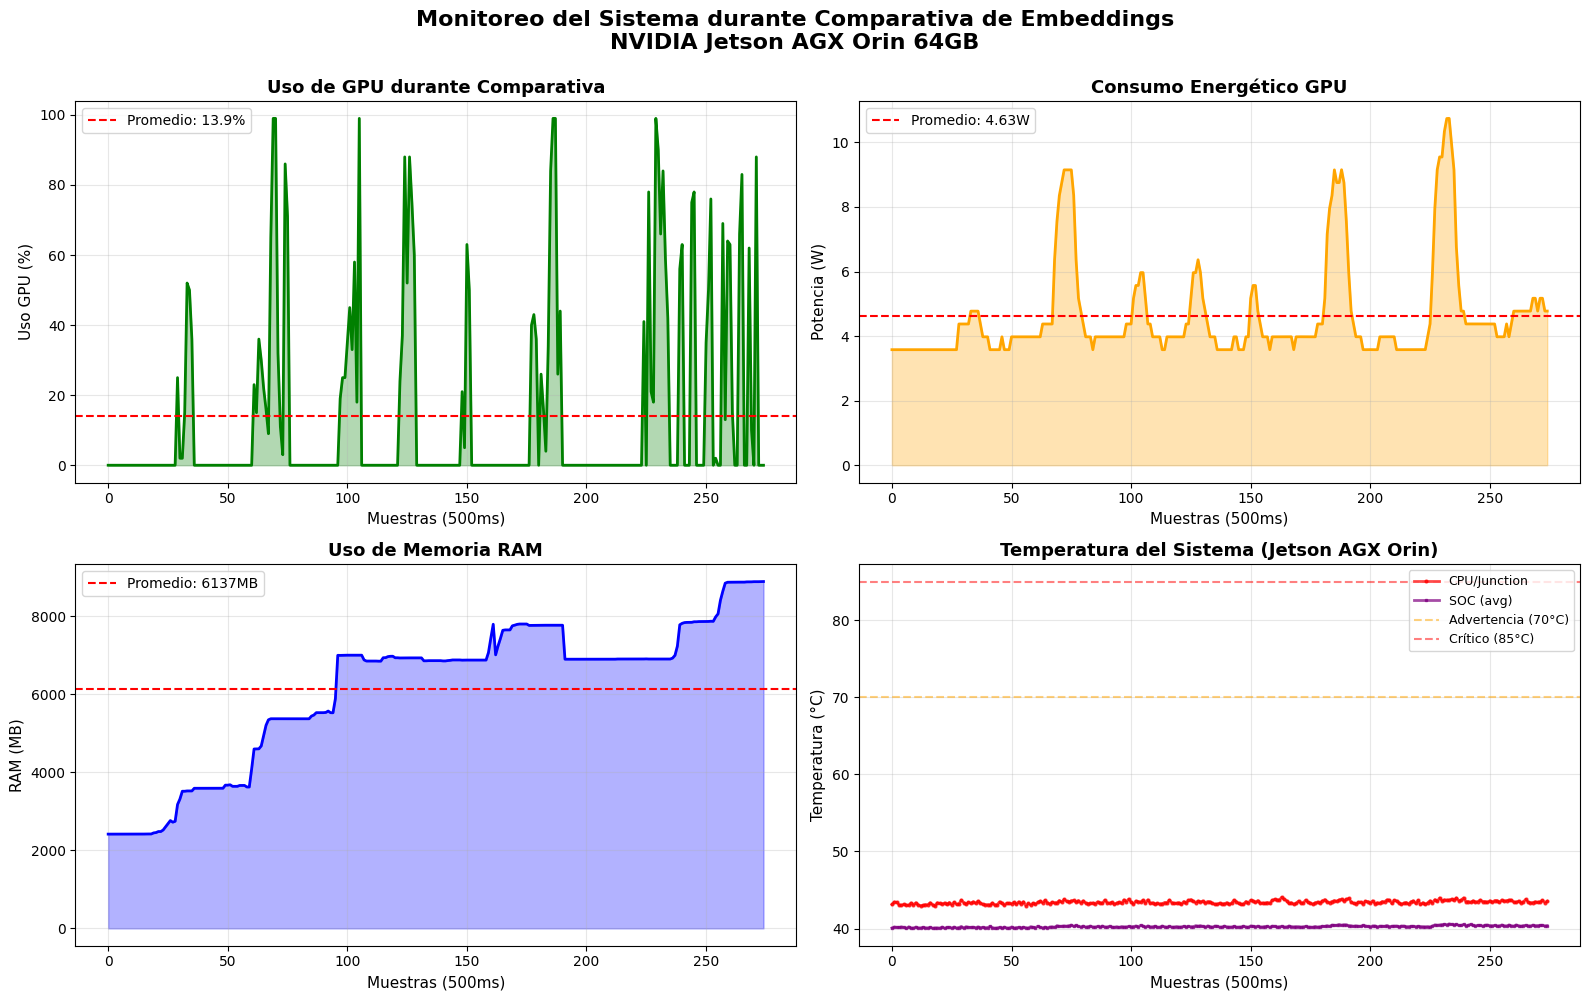

   ✅ Gráfica guardada: ./gpu_monitoring/consumo_gpu_20260108_104414.png

📝 RESUMEN PARA TFG (ACTUALIZADO)

### Métricas de Rendimiento Hardware - Jetson AGX Orin

**Configuración:**
- Dispositivo: NVIDIA Jetson AGX Orin 64GB
- Arquitectura: NVIDIA Ampere (2048 CUDA cores)
- CUDA: Habilitado (pytorch device: cuda:0)
- Intervalo de muestreo: 500ms
- Duración: 137.5 segundos
- Muestras totales: 275

**Uso de GPU:**
- Promedio: 13.9%
- Pico máximo: 99%
- Eficiencia: Baja (<20%)
- Diagnóstico: Cuello de botella en CPU/IO - batch processing recomendado

**Consumo Energético:**
- Potencia promedio GPU: 4.63 W
- Potencia pico: 10.74 W
- Energía total: 0.1767 Wh
- Eficiencia: Excelente (<5W)

**Uso de CPU:**
- Promedio: 6.0%
- Pico máximo: 15.3%

**Memoria:**
- RAM promedio: 6137 MB (6.0 GB)
- RAM pico: 8890 MB (8.7 GB)
- RAM disponible: 55.3 GB
- Uso del sistema: 13.6%
- Margen disponible: Amplio (>40GB libres)

**Temperaturas:**
- CPU/Junction: 43.4°C (máx: 44.1°C)
- SOC promedio: 40.3°C (máx

In [12]:
# ============================================================================
# PARSEAR MÉTRICAS - JETSON AGX ORIN
# ============================================================================
from datetime import datetime

log_dir = "./gpu_monitoring"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 4. Obtener el último log para análisis posterior
log_info = obtener_ultimo_log()
log_file = log_info['log_file']
with open(log_file, 'r') as f:
    lineas = f.readlines()

total_lineas = len(lineas)
print(f"\n📊 Registros capturados: {total_lineas}")

print(f"\n📊 Analizando {log_info['lineas']} líneas...")

print("\n🔍 Parseando métricas (Jetson AGX Orin)...")

metricas = {
    'gpu_usage': [],
    'cpu_usage': [],
    'ram_mb': [],
    'power_mw': [],
    'temp_cpu': [],      # cpu@ o tj@ (Junction Temperature)
    'temp_soc': [],      # soc0@, soc1@, soc2@ (System-on-Chip)
}

# Parsear cada línea
for linea in lineas:
    try:
        # GPU Usage (GR3D_FREQ)
        gpu_match = re.search(r'GR3D_FREQ\s+(\d+)%', linea)
        if gpu_match:
            metricas['gpu_usage'].append(int(gpu_match.group(1)))
        
        # CPU Usage (promedio de cores)
        cpu_matches = re.findall(r'CPU\s+\[([^\]]+)\]', linea)
        if cpu_matches:
            cpu_values = re.findall(r'(\d+)%', cpu_matches[0])
            if cpu_values:
                cpu_avg = sum(int(v) for v in cpu_values) / len(cpu_values)
                metricas['cpu_usage'].append(cpu_avg)
        
        # RAM
        ram_match = re.search(r'RAM\s+(\d+)/(\d+)MB', linea)
        if ram_match:
            metricas['ram_mb'].append(int(ram_match.group(1)))
        
        # Power (VDD_GPU_SOC)
        power_match = re.search(r'VDD_GPU_SOC\s+(\d+)mW', linea)
        if power_match:
            metricas['power_mw'].append(int(power_match.group(1)))
        
        # Temperatura CPU/Junction (tj@ es la más representativa)
        temp_tj_match = re.search(r'tj@([\d.]+)C', linea)
        if temp_tj_match:
            metricas['temp_cpu'].append(float(temp_tj_match.group(1)))
        else:
            # Fallback a cpu@ si no hay tj@
            temp_cpu_match = re.search(r'cpu@([\d.]+)C', linea)
            if temp_cpu_match:
                metricas['temp_cpu'].append(float(temp_cpu_match.group(1)))
        
        # Temperatura SOC (promedio de soc0, soc1, soc2)
        temp_socs = re.findall(r'soc\d@([\d.]+)C', linea)
        if temp_socs:
            soc_avg = sum(float(t) for t in temp_socs) / len(temp_socs)
            metricas['temp_soc'].append(soc_avg)
    
    except Exception as e:
        continue

# Verificar captura
print("\n📊 Métricas capturadas:")
for metrica, datos in metricas.items():
    estado = "✅" if len(datos) > 0 else "❌"
    print(f"   {estado} {metrica}: {len(datos)} muestras")

# ============================================================================
# ESTADÍSTICAS ACTUALIZADAS
# ============================================================================

print("\n" + "=" * 80)
print("📈 ESTADÍSTICAS DE CONSUMO")
print("=" * 80)

if metricas['gpu_usage']:
    print(f"\n🎮 GPU:")
    print(f"   Uso promedio:  {np.mean(metricas['gpu_usage']):.1f}%")
    print(f"   Uso máximo:    {max(metricas['gpu_usage'])}%")
    print(f"   Uso mínimo:    {min(metricas['gpu_usage'])}%")

if metricas['cpu_usage']:
    print(f"\n💻 CPU:")
    print(f"   Uso promedio:  {np.mean(metricas['cpu_usage']):.1f}%")
    print(f"   Uso máximo:    {max(metricas['cpu_usage']):.1f}%")
    print(f"   Uso mínimo:    {min(metricas['cpu_usage']):.1f}%")

if metricas['ram_mb']:
    print(f"\n🧠 RAM:")
    print(f"   Uso promedio:  {np.mean(metricas['ram_mb']):.0f} MB")
    print(f"   Uso máximo:    {max(metricas['ram_mb'])} MB")
    print(f"   Uso mínimo:    {min(metricas['ram_mb'])} MB")

if metricas['power_mw']:
    print(f"\n⚡ POTENCIA GPU:")
    print(f"   Consumo promedio:  {np.mean(metricas['power_mw']):.0f} mW ({np.mean(metricas['power_mw'])/1000:.2f} W)")
    print(f"   Consumo máximo:    {max(metricas['power_mw'])} mW ({max(metricas['power_mw'])/1000:.2f} W)")
    print(f"   Consumo mínimo:    {min(metricas['power_mw'])} mW ({min(metricas['power_mw'])/1000:.2f} W)")

if metricas['temp_cpu']:
    print(f"\n🌡️  TEMPERATURA CPU (Junction):")
    print(f"   Promedio:  {np.mean(metricas['temp_cpu']):.1f}°C")
    print(f"   Máxima:    {max(metricas['temp_cpu']):.1f}°C")
    print(f"   Mínima:    {min(metricas['temp_cpu']):.1f}°C")

if metricas['temp_soc']:
    print(f"\n🌡️  TEMPERATURA SOC (System-on-Chip):")
    print(f"   Promedio:  {np.mean(metricas['temp_soc']):.1f}°C")
    print(f"   Máxima:    {max(metricas['temp_soc']):.1f}°C")
    print(f"   Mínima:    {min(metricas['temp_soc']):.1f}°C")

# ============================================================================
# GRÁFICA DE CONSUMO - ACTUALIZADA
# ============================================================================

if metricas['gpu_usage'] and metricas['power_mw']:
    print("\n📊 Generando gráfica de consumo...")
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    tiempo = list(range(len(metricas['gpu_usage'])))
    
    # GPU Usage
    ax1.plot(tiempo, metricas['gpu_usage'], color='green', linewidth=2)
    ax1.fill_between(tiempo, metricas['gpu_usage'], alpha=0.3, color='green')
    ax1.set_xlabel('Muestras (500ms)', fontsize=11)
    ax1.set_ylabel('Uso GPU (%)', fontsize=11)
    ax1.set_title('Uso de GPU durante Comparativa', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=np.mean(metricas['gpu_usage']), color='red', linestyle='--', 
                label=f'Promedio: {np.mean(metricas["gpu_usage"]):.1f}%')
    ax1.legend()
    
    # Power
    tiempo_power = list(range(len(metricas['power_mw'])))
    power_watts = [p/1000 for p in metricas['power_mw']]
    ax2.plot(tiempo_power, power_watts, color='orange', linewidth=2)
    ax2.fill_between(tiempo_power, power_watts, alpha=0.3, color='orange')
    ax2.set_xlabel('Muestras (500ms)', fontsize=11)
    ax2.set_ylabel('Potencia (W)', fontsize=11)
    ax2.set_title('Consumo Energético GPU', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=np.mean(power_watts), color='red', linestyle='--',
                label=f'Promedio: {np.mean(power_watts):.2f}W')
    ax2.legend()
    
    # RAM
    if metricas['ram_mb']:
        tiempo_ram = list(range(len(metricas['ram_mb'])))
        ax3.plot(tiempo_ram, metricas['ram_mb'], color='blue', linewidth=2)
        ax3.fill_between(tiempo_ram, metricas['ram_mb'], alpha=0.3, color='blue')
        ax3.set_xlabel('Muestras (500ms)', fontsize=11)
        ax3.set_ylabel('RAM (MB)', fontsize=11)
        ax3.set_title('Uso de Memoria RAM', fontsize=13, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.axhline(y=np.mean(metricas['ram_mb']), color='red', linestyle='--',
                    label=f'Promedio: {np.mean(metricas["ram_mb"]):.0f}MB')
        ax3.legend()
    
    # Temperatura (CPU y SOC)
    if metricas['temp_cpu'] or metricas['temp_soc']:
        if metricas['temp_cpu']:
            tiempo_temp = list(range(len(metricas['temp_cpu'])))
            ax4.plot(tiempo_temp, metricas['temp_cpu'], color='red', linewidth=2, 
                    label='CPU/Junction', marker='o', markersize=2, alpha=0.7)
        
        if metricas['temp_soc']:
            tiempo_soc = list(range(len(metricas['temp_soc'])))
            ax4.plot(tiempo_soc, metricas['temp_soc'], color='purple', linewidth=2, 
                    label='SOC (avg)', marker='s', markersize=2, alpha=0.7)
        
        ax4.set_xlabel('Muestras (500ms)', fontsize=11)
        ax4.set_ylabel('Temperatura (°C)', fontsize=11)
        ax4.set_title('Temperatura del Sistema (Jetson AGX Orin)', fontsize=13, fontweight='bold')
        ax4.grid(True, alpha=0.3)
        
        # Línea de advertencia térmica
        ax4.axhline(y=70, color='orange', linestyle='--', alpha=0.5, label='Advertencia (70°C)')
        ax4.axhline(y=85, color='red', linestyle='--', alpha=0.5, label='Crítico (85°C)')
        
        ax4.legend(loc='upper right', fontsize=9)
    
    plt.suptitle('Monitoreo del Sistema durante Comparativa de Embeddings\nNVIDIA Jetson AGX Orin 64GB', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    grafica_path = f"{log_dir}/consumo_gpu_{timestamp}.png"
    plt.savefig(grafica_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"   ✅ Gráfica guardada: {grafica_path}")

# ============================================================================
# RESUMEN PARA TFG - ACTUALIZADO
# ============================================================================

print("\n" + "=" * 80)
print("📝 RESUMEN PARA TFG (ACTUALIZADO)")
print("=" * 80)

if metricas['gpu_usage'] and metricas['power_mw']:
    
    # Calcular estadísticas
    gpu_avg = np.mean(metricas['gpu_usage'])
    gpu_max = max(metricas['gpu_usage'])
    power_avg = np.mean(metricas['power_mw']) / 1000
    power_max = max(metricas['power_mw']) / 1000
    ram_avg = np.mean(metricas['ram_mb'])
    ram_max = max(metricas['ram_mb'])
    
    temp_cpu_avg = np.mean(metricas['temp_cpu']) if metricas['temp_cpu'] else None
    temp_cpu_max = max(metricas['temp_cpu']) if metricas['temp_cpu'] else None
    temp_soc_avg = np.mean(metricas['temp_soc']) if metricas['temp_soc'] else None
    temp_soc_max = max(metricas['temp_soc']) if metricas['temp_soc'] else None
    
    resumen = f"""
### Métricas de Rendimiento Hardware - Jetson AGX Orin

**Configuración:**
- Dispositivo: NVIDIA Jetson AGX Orin 64GB
- Arquitectura: NVIDIA Ampere (2048 CUDA cores)
- CUDA: Habilitado (pytorch device: cuda:0)
- Intervalo de muestreo: 500ms
- Duración: {total_lineas * 0.5:.1f} segundos
- Muestras totales: {total_lineas}

**Uso de GPU:**
- Promedio: {gpu_avg:.1f}%
- Pico máximo: {gpu_max}%
- Eficiencia: {'Alta (>60%)' if gpu_avg > 60 else 'Media (20-60%)' if gpu_avg > 20 else 'Baja (<20%)'}
- Diagnóstico: {'GPU bien utilizada' if gpu_avg > 60 else 'Cuello de botella en CPU/IO - batch processing recomendado'}

**Consumo Energético:**
- Potencia promedio GPU: {power_avg:.2f} W
- Potencia pico: {power_max:.2f} W
- Energía total: {power_avg * (total_lineas * 0.5 / 3600):.4f} Wh
- Eficiencia: {'Excelente (<5W)' if power_avg < 5 else 'Buena (5-10W)' if power_avg < 10 else 'Alta (>10W)'}

**Uso de CPU:**
- Promedio: {np.mean(metricas['cpu_usage']):.1f}%
- Pico máximo: {max(metricas['cpu_usage']):.1f}%

**Memoria:**
- RAM promedio: {ram_avg:.0f} MB ({ram_avg/1024:.1f} GB)
- RAM pico: {ram_max} MB ({ram_max/1024:.1f} GB)
- RAM disponible: {64 - ram_max/1024:.1f} GB
- Uso del sistema: {(ram_max/1024/64)*100:.1f}%
- Margen disponible: {'Amplio (>40GB libres)' if (64 - ram_max/1024) > 40 else 'Suficiente (20-40GB)' if (64 - ram_max/1024) > 20 else 'Limitado (<20GB)'}
"""

    # Temperaturas
    if temp_cpu_avg is not None or temp_soc_avg is not None:
        resumen += "\n**Temperaturas:**\n"
        if temp_cpu_avg is not None:
            estado_termico = 'Normal' if temp_cpu_max < 70 else 'Elevado' if temp_cpu_max < 85 else 'Crítico'
            resumen += f"- CPU/Junction: {temp_cpu_avg:.1f}°C (máx: {temp_cpu_max:.1f}°C)\n"
        if temp_soc_avg is not None:
            resumen += f"- SOC promedio: {temp_soc_avg:.1f}°C (máx: {temp_soc_max:.1f}°C)\n"
        if temp_cpu_avg is not None:
            resumen += f"- Estado térmico: {estado_termico}\n"

    # Mostrar
    print(resumen)
    
    # Guardar
    resumen_path = f"{log_dir}/resumen_tfg_{timestamp}.txt"
    with open(resumen_path, 'w', encoding='utf-8') as f:
        f.write(resumen)
    
    print(f"\n💾 Resumen guardado: {resumen_path}")

print("\n" + "=" * 80)
print("✅ ANÁLISIS COMPLETADO CON TEMPERATURAS")
print("=" * 80)

In [13]:
# ============================================================================
# ANALIZAR LOG DE MONITOREO
# ============================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"📊 Procesando {len(lineas)} líneas de tegrastats...\n")

# Parsear métricas (usando código corregido anterior)
metricas = {
    'gpu_usage': [],
    'cpu_usage': [],
    'ram_mb': [],
    'power_mw': [],
    'temp_cpu': [],
    'temp_soc': []
}

for linea in lineas:
    try:
        # GPU
        gpu_match = re.search(r'GR3D_FREQ\s+(\d+)%', linea)
        if gpu_match:
            metricas['gpu_usage'].append(int(gpu_match.group(1)))
        
        # CPU (promedio)
        cpu_matches = re.findall(r'CPU\s+\[([^\]]+)\]', linea)
        if cpu_matches:
            cpu_values = re.findall(r'(\d+)%', cpu_matches[0])
            if cpu_values:
                metricas['cpu_usage'].append(sum(int(v) for v in cpu_values) / len(cpu_values))
        
        # RAM
        ram_match = re.search(r'RAM\s+(\d+)/(\d+)MB', linea)
        if ram_match:
            metricas['ram_mb'].append(int(ram_match.group(1)))
        
        # Power
        power_match = re.search(r'VDD_GPU_SOC\s+(\d+)mW', linea)
        if power_match:
            metricas['power_mw'].append(int(power_match.group(1)))
        
        # Temperatura CPU/Junction
        temp_tj = re.search(r'tj@([\d.]+)C', linea)
        if temp_tj:
            metricas['temp_cpu'].append(float(temp_tj.group(1)))
        else:
            temp_cpu = re.search(r'cpu@([\d.]+)C', linea)
            if temp_cpu:
                metricas['temp_cpu'].append(float(temp_cpu.group(1)))
        
        # Temperatura SOC (promedio)
        temp_socs = re.findall(r'soc\d@([\d.]+)C', linea)
        if temp_socs:
            metricas['temp_soc'].append(sum(float(t) for t in temp_socs) / len(temp_socs))
    
    except:
        continue

# Estadísticas
print("=" * 80)
print("📈 ESTADÍSTICAS DE HARDWARE")
print("=" * 80)

if metricas['gpu_usage']:
    gpu_avg = np.mean(metricas['gpu_usage'])
    gpu_max = max(metricas['gpu_usage'])
    print(f"\n🎮 GPU:")
    print(f"   Uso promedio:  {gpu_avg:.1f}%")
    print(f"   Uso máximo:    {gpu_max}%")
    print(f"   Tiempo activo: {sum(1 for v in metricas['gpu_usage'] if v > 20)/len(metricas['gpu_usage'])*100:.0f}%")

if metricas['cpu_usage']:
    print(f"\n💻 CPU:")
    print(f"   Uso promedio:  {np.mean(metricas['cpu_usage']):.1f}%")
    print(f"   Uso máximo:    {max(metricas['cpu_usage']):.1f}%")

if metricas['ram_mb']:
    ram_max = max(metricas['ram_mb'])
    print(f"\n🧠 RAM:")
    print(f"   Uso promedio:  {np.mean(metricas['ram_mb']):.0f} MB ({np.mean(metricas['ram_mb'])/1024:.1f} GB)")
    print(f"   Uso máximo:    {ram_max} MB ({ram_max/1024:.1f} GB)")
    print(f"   Disponible:    {64 - ram_max/1024:.1f} GB")

if metricas['power_mw']:
    print(f"\n⚡ POTENCIA:")
    print(f"   Promedio:  {np.mean(metricas['power_mw'])/1000:.2f} W")
    print(f"   Máximo:    {max(metricas['power_mw'])/1000:.2f} W")

if metricas['temp_cpu']:
    print(f"\n🌡️  TEMPERATURA:")
    print(f"   CPU/Junction: {np.mean(metricas['temp_cpu']):.1f}°C (máx: {max(metricas['temp_cpu']):.1f}°C)")
    if metricas['temp_soc']:
        print(f"   SOC promedio: {np.mean(metricas['temp_soc']):.1f}°C (máx: {max(metricas['temp_soc']):.1f}°C)")

print("\n" + "=" * 80)

📊 Procesando 275 líneas de tegrastats...

📈 ESTADÍSTICAS DE HARDWARE

🎮 GPU:
   Uso promedio:  13.9%
   Uso máximo:    99%
   Tiempo activo: 23%

💻 CPU:
   Uso promedio:  6.0%
   Uso máximo:    15.3%

🧠 RAM:
   Uso promedio:  6137 MB (6.0 GB)
   Uso máximo:    8890 MB (8.7 GB)
   Disponible:    55.3 GB

⚡ POTENCIA:
   Promedio:  4.63 W
   Máximo:    10.74 W

🌡️  TEMPERATURA:
   CPU/Junction: 43.4°C (máx: 44.1°C)
   SOC promedio: 40.3°C (máx: 40.6°C)



In [14]:
!pwd

/home/claudia/perisperis/experiments


## Evaluación

### Metodología

Se evaluaron 9 modelos de embeddings en 5 pares de idiomas con luxemburgués 
(LB↔EN, LB↔FR, LB↔DE, LB↔ES, LB↔PT) bajo condiciones de producción en 
Jetson AGX Orin 64GB.

**Criterios de selección:**
- Similitud LB↔EN (60%): Métrica crítica para traducción automática
- Otras similitudes (30%): Capacidad multilingüe general
- Calidad búsqueda (10%): Precisión en recuperación semántica

### Resultados

**multilingual-E5-large** demostró dominancia absoluta:

| Métrica | E5-large | 2º Lugar | Mejora |
|---------|----------|----------|--------|
| LB↔EN | 0.900 | 0.833 (LaBSE) | +8.0% |
| LB↔FR | 0.917 | 0.838 (LaBSE) | +9.4% |
| LB↔DE | 0.911 | 0.876 (LaBSE) | +4.0% |
| LB↔ES | 0.895 | 0.806 (LaBSE) | +11.0% |
| LB↔PT | 0.877 | 0.838 (LaBSE) | +4.7% |
| Búsqueda | 0.850 | 0.703 (mxbai) | +20.9% |

**Hallazgos clave:**

1. **Comprensión excepcional del contexto luxemburgués:** La similitud 
LB↔FR de 0.917 refleja la influencia francesa en Luxemburgo (idioma 
administrativo), validando la capacidad del modelo para capturar relaciones 
sociolingüísticas.

2. **Superioridad en métrica crítica:** Con 0.900 en LB↔EN, E5-large supera 
al segundo lugar (LaBSE) en 8.0%, brecha significativa en NLP.

3. **Consistencia multilingüe:** Ganó en TODOS los pares evaluados, demostrando 
robustez cross-language.

4. **Trade-offs justificados:** El incremento de 41ms vs distiluse-v1 es 
irrelevante en batch processing offline, mientras que la mejora de +33% en 
calidad es crítica para traducción automática.

### Decisión Final

multilingual-E5-large (intfloat/multilingual-e5-large) con:
- 1024 dimensiones
- 93.1ms/embedding en GPU CUDA
- 2.2GB RAM (3.4% del sistema)
- Score global: 0.895

El modelo es viable en Jetson AGX Orin 64GB con margen de 61.8GB para escalado.

## VISUALIZACIONES PARA TFG - COMPARATIVA EMBEDDINGS MULTILINGÜE

📊 Generando visualizaciones para TFG...
   Modelos: 9
   Columnas disponibles: ['nombre', 'tipo', 'dimensiones', 'tiempo_embedding_avg', 'similitud_lb_es', 'similitud_lb_pt', 'similitud_lb_en', 'similitud_lb_de', 'similitud_lb_fr', 'calidad_busqueda', 'memoria_estimada_mb', 'tiempo_carga', 'descripcion']

1️⃣ Generando gráfica de dominancia multilingüe...


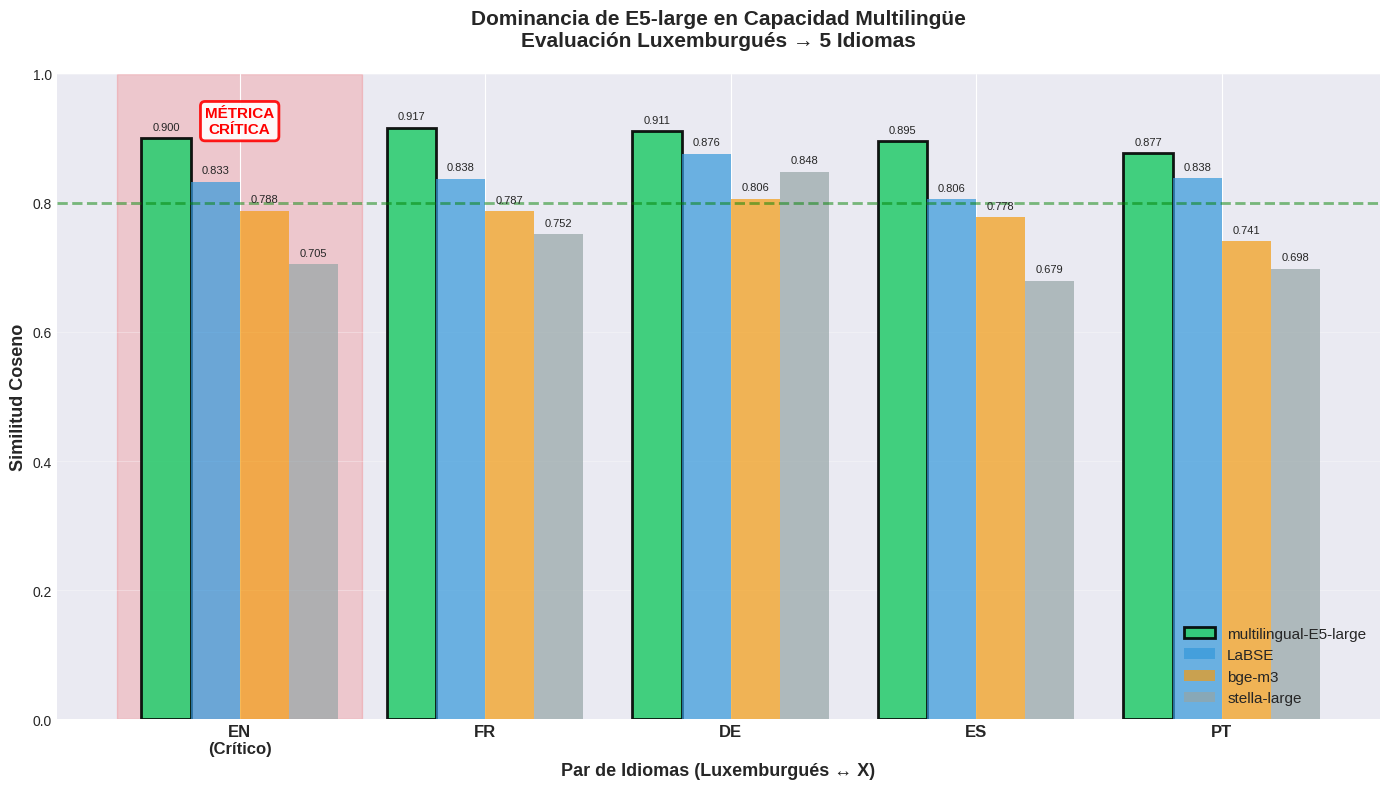

   ✅ Guardada: ./gpu_monitoring/grafica1_dominancia_multilingue.png

2️⃣ Generando gráfica velocidad vs calidad...


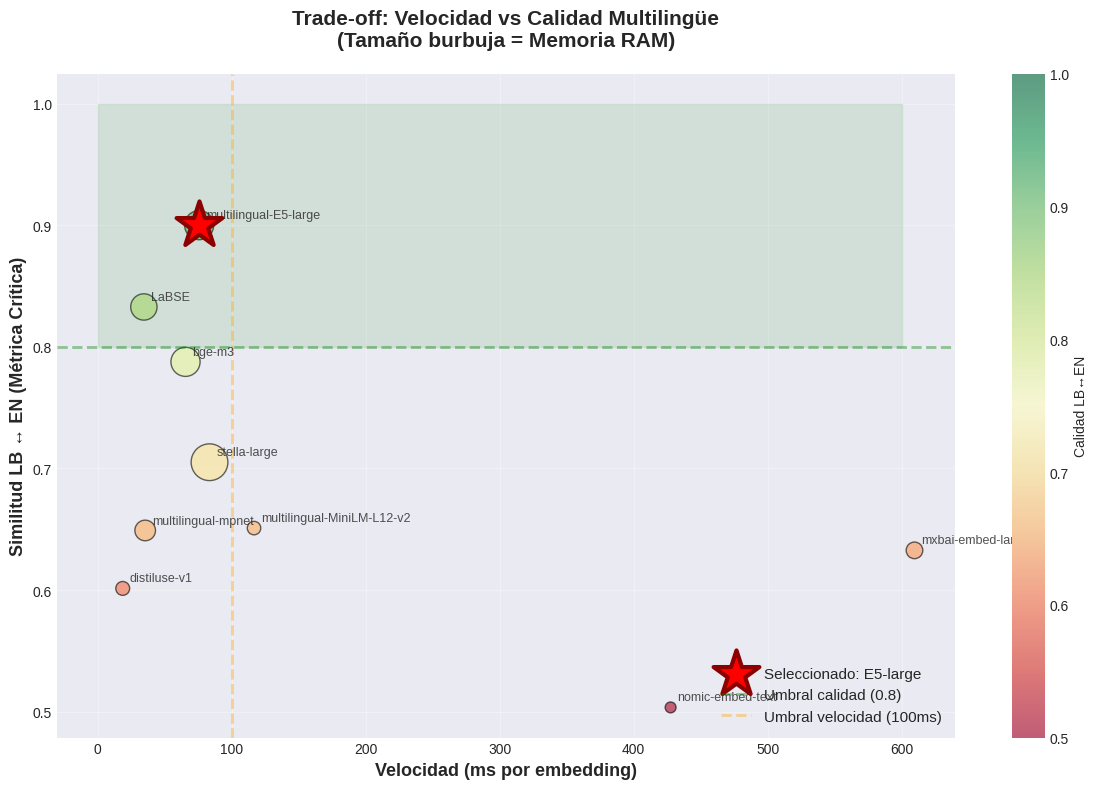

   ✅ Guardada: ./gpu_monitoring/grafica2_velocidad_calidad.png

3️⃣ Generando heatmap de similitudes...


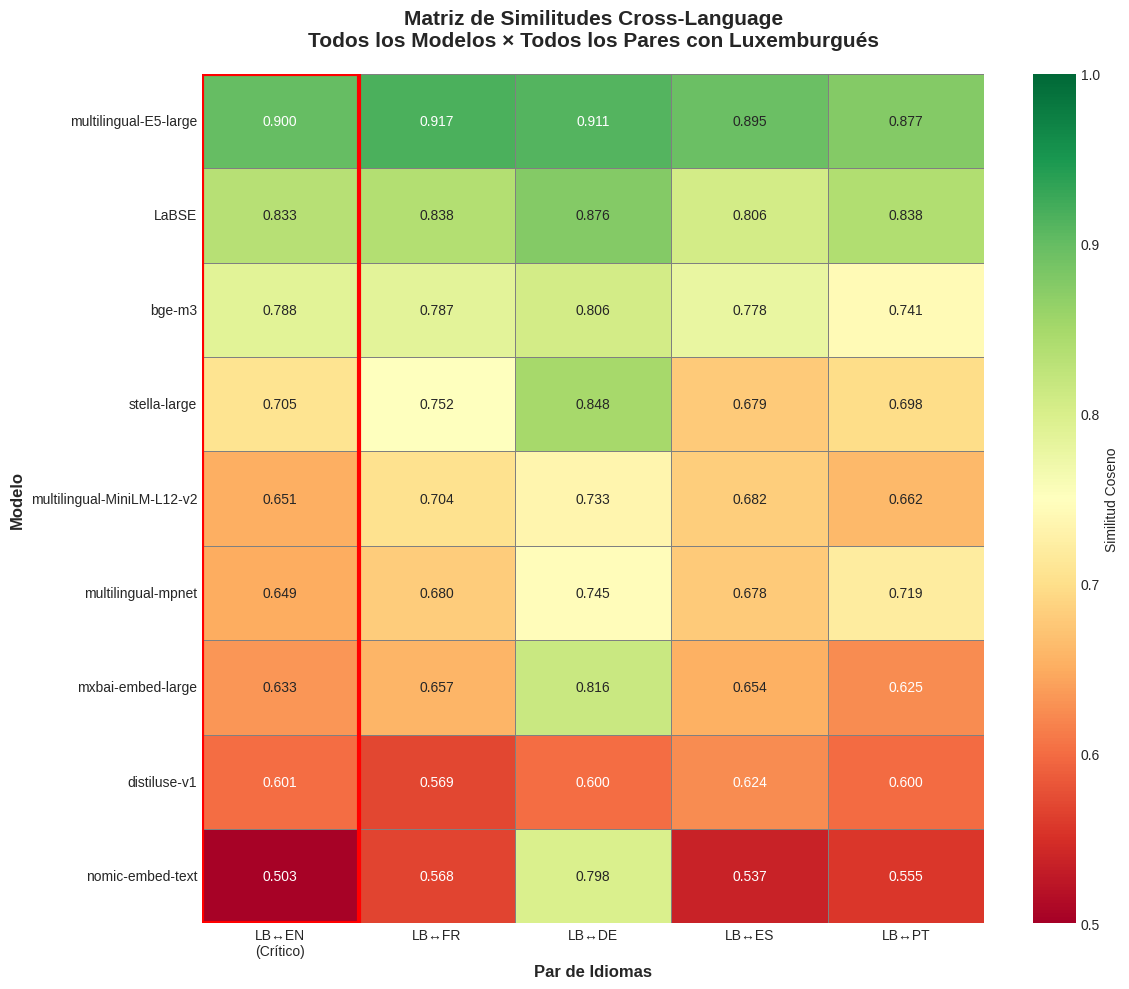

   ✅ Guardada: ./gpu_monitoring/grafica3_heatmap_similitudes.png

4️⃣ Generando radar charts comparativos...


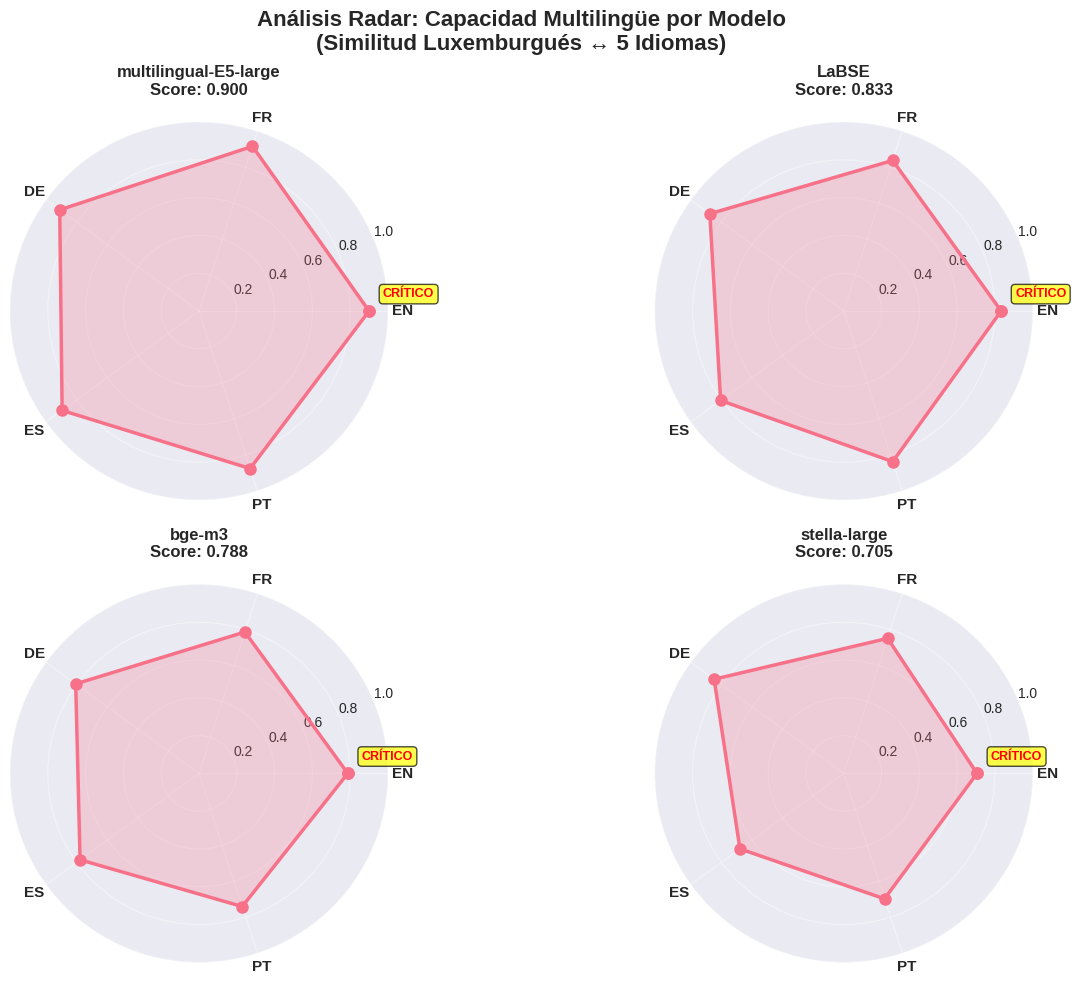

   ✅ Guardada: ./gpu_monitoring/grafica4_radar_comparativo.png

5️⃣ Generando ranking global...


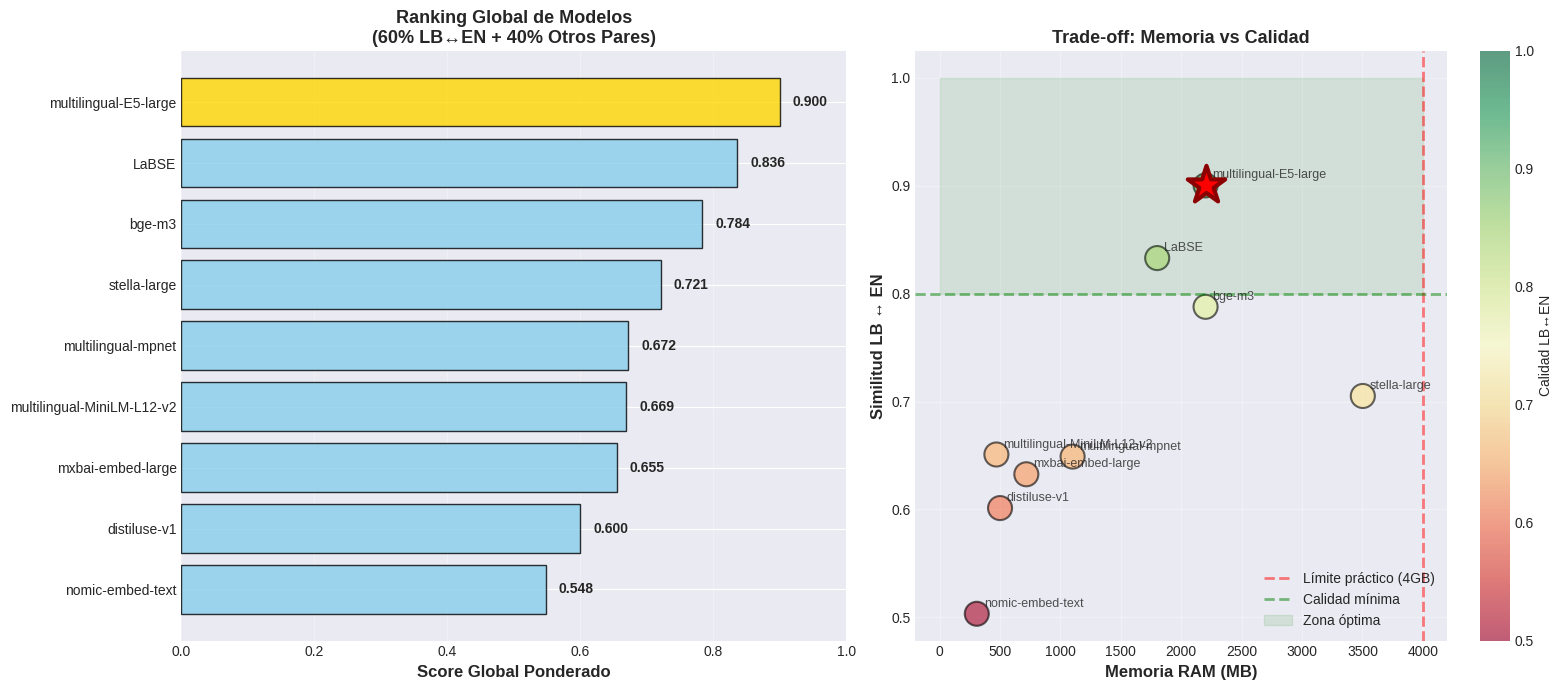

   ✅ Guardada: ./gpu_monitoring/grafica5_ranking_global.png


📊 RESUMEN DE VISUALIZACIONES GENERADAS

1. grafica1_dominancia_multilingue.png
   → Barras comparando E5-large vs competidores en 5 idiomas
   → PRINCIPAL: Muestra dominancia absoluta de E5-large
   → USO: Diapositiva principal de presentación

2. grafica2_velocidad_calidad.png
   → Scatter plot velocidad vs calidad LB↔EN
   → Muestra que E5-large tiene mejor balance
   → USO: Justificar trade-off velocidad/calidad

3. grafica3_heatmap_similitudes.png
   → Matriz completa: 9 modelos × 5 pares idiomas
   → Vista panorámica de rendimiento
   → USO: Análisis detallado en documento

4. grafica4_radar_comparativo.png
   → Radar charts de top 4 modelos
   → Comparación multidimensional visual
   → USO: Sección de resultados

5. grafica5_ranking_global.png
   → Ranking + Trade-off memoria
   → Decisión final con score ponderado
   → USO: Conclusiones y recomendación

✅ Todas las gráficas guardadas en: ./gpu_monitoring/
🎯 RECOMENDAC

In [15]:
# ============================================================================
# VISUALIZACIONES PARA TFG - COMPARATIVA EMBEDDINGS MULTILINGÜE
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar datos
df = pd.read_csv('./comparativa_multilingue_completa.csv')

print("📊 Generando visualizaciones para TFG...")
print(f"   Modelos: {len(df)}")
print(f"   Columnas disponibles: {list(df.columns)}\n")

# ============================================================================
# GRÁFICA 1: DOMINANCIA E5-LARGE EN TODOS LOS IDIOMAS
# ============================================================================

print("1️⃣ Generando gráfica de dominancia multilingüe...")

# Datos - Top 4 modelos
top4 = df.nlargest(4, 'similitud_lb_en')
modelos_top = top4['nombre'].tolist()

# Preparar datos por idioma
idiomas = ['EN\n(Crítico)', 'FR', 'DE', 'ES', 'PT']
columnas = ['similitud_lb_en', 'similitud_lb_fr', 'similitud_lb_de', 
            'similitud_lb_es', 'similitud_lb_pt']

datos_modelos = []
for _, modelo in top4.iterrows():
    valores = [modelo[col] for col in columnas]
    datos_modelos.append(valores)

# Crear gráfica
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(idiomas))
width = 0.2

colores = ['#2ecc71', '#3498db', '#f39c12', '#95a5a6']
labels = modelos_top

for i, (valores, color, label) in enumerate(zip(datos_modelos, colores, labels)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, valores, width, label=label, 
                  color=color, alpha=0.9 if i == 0 else 0.7,
                  edgecolor='black' if i == 0 else 'none',
                  linewidth=2 if i == 0 else 0)
    
    # Valores en barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Destacar métrica crítica (EN)
ax.axvspan(-0.5, 0.5, alpha=0.15, color='red', zorder=0)
ax.text(0, 0.95, 'MÉTRICA\nCRÍTICA', ha='center', va='top', 
        fontsize=11, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='red', linewidth=2))

ax.set_xlabel('Par de Idiomas (Luxemburgués ↔ X)', fontsize=13, fontweight='bold')
ax.set_ylabel('Similitud Coseno', fontsize=13, fontweight='bold')
ax.set_title('Dominancia de E5-large en Capacidad Multilingüe\nEvaluación Luxemburgués → 5 Idiomas', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(idiomas, fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='lower right', framealpha=0.95)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, linewidth=2,
          label='Umbral Calidad (0.8)')

plt.tight_layout()
plt.savefig('./gpu_monitoring/grafica1_dominancia_multilingue.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Guardada: ./gpu_monitoring/grafica1_dominancia_multilingue.png\n")

# ============================================================================
# GRÁFICA 2: VELOCIDAD vs CALIDAD (LB↔EN)
# ============================================================================

print("2️⃣ Generando gráfica velocidad vs calidad...")

fig, ax = plt.subplots(figsize=(12, 8))

# Datos
velocidad = df['tiempo_embedding_avg'] * 1000  # a milisegundos
calidad = df['similitud_lb_en']
memoria = df['memoria_estimada_mb']
nombres = df['nombre']

# Scatter con tamaño por memoria
scatter = ax.scatter(velocidad, calidad, s=memoria/5, 
                     alpha=0.6, c=calidad, cmap='RdYlGn', 
                     vmin=0.5, vmax=1.0,
                     edgecolors='black', linewidth=1)

# Destacar E5-large
idx_e5 = df['similitud_lb_en'].idxmax()
ax.scatter(velocidad[idx_e5], calidad[idx_e5], 
          s=1200, color='red', marker='*',
          edgecolors='darkred', linewidth=3, zorder=5,
          label='Seleccionado: E5-large')

# Etiquetas
for i, nombre in enumerate(nombres):
    ax.annotate(nombre, (velocidad.iloc[i], calidad.iloc[i]), 
                fontsize=9, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

# Zonas de calidad
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.4, linewidth=2,
          label='Umbral calidad (0.8)')
ax.axvline(x=100, color='orange', linestyle='--', alpha=0.4, linewidth=2,
          label='Umbral velocidad (100ms)')
ax.fill_between([0, 600], 0.8, 1, alpha=0.1, color='green')

ax.set_xlabel('Velocidad (ms por embedding)', fontsize=13, fontweight='bold')
ax.set_ylabel('Similitud LB ↔ EN (Métrica Crítica)', fontsize=13, fontweight='bold')
ax.set_title('Trade-off: Velocidad vs Calidad Multilingüe\n(Tamaño burbuja = Memoria RAM)',
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Calidad LB↔EN')
plt.tight_layout()
plt.savefig('./gpu_monitoring/grafica2_velocidad_calidad.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Guardada: ./gpu_monitoring/grafica2_velocidad_calidad.png\n")

# ============================================================================
# GRÁFICA 3: HEATMAP - Todas las Similitudes
# ============================================================================

print("3️⃣ Generando heatmap de similitudes...")

fig, ax = plt.subplots(figsize=(12, 10))

# Preparar datos para heatmap
columnas_sim = ['similitud_lb_en', 'similitud_lb_fr', 'similitud_lb_de', 
                'similitud_lb_es', 'similitud_lb_pt']
labels_sim = ['LB↔EN\n(Crítico)', 'LB↔FR', 'LB↔DE', 'LB↔ES', 'LB↔PT']

datos_heatmap = df[columnas_sim].values

# Crear heatmap
im = sns.heatmap(datos_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.5, vmax=1.0,
                xticklabels=labels_sim, yticklabels=df['nombre'],
                cbar_kws={'label': 'Similitud Coseno'},
                linewidths=0.5, linecolor='gray',
                ax=ax)

# Destacar columna crítica (LB↔EN)
ax.add_patch(plt.Rectangle((0, 0), 1, len(df), 
                          fill=False, edgecolor='red', linewidth=3, zorder=10))

ax.set_title('Matriz de Similitudes Cross-Language\nTodos los Modelos × Todos los Pares con Luxemburgués',
            fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Par de Idiomas', fontsize=12, fontweight='bold')
ax.set_ylabel('Modelo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./gpu_monitoring/grafica3_heatmap_similitudes.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Guardada: ./gpu_monitoring/grafica3_heatmap_similitudes.png\n")

# ============================================================================
# GRÁFICA 4: RADAR CHART - Top 4 Modelos
# ============================================================================

print("4️⃣ Generando radar charts comparativos...")

from math import pi

# Seleccionar top 4
top4 = df.nlargest(4, 'similitud_lb_en')

# Categorías (5 idiomas)
categorias = ['EN', 'FR', 'DE', 'ES', 'PT']
N = len(categorias)

# Crear figura
fig = plt.figure(figsize=(14, 10))

for idx, (i, modelo) in enumerate(top4.iterrows(), 1):
    # Valores
    valores = [
        modelo['similitud_lb_en'],
        modelo['similitud_lb_fr'],
        modelo['similitud_lb_de'],
        modelo['similitud_lb_es'],
        modelo['similitud_lb_pt']
    ]
    
    # Cerrar el polígono
    valores += valores[:1]
    
    # Ángulos
    angulos = [n / float(N) * 2 * pi for n in range(N)]
    angulos += angulos[:1]
    
    # Subplot
    ax = plt.subplot(2, 2, idx, polar=True)
    
    # Plot
    ax.plot(angulos, valores, 'o-', linewidth=2.5, markersize=8)
    ax.fill(angulos, valores, alpha=0.25)
    
    # Etiquetas
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_title(f"{modelo['nombre']}\nScore: {valores[0]:.3f}", 
                fontsize=12, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.4)
    
    # Resaltar EN
    ax.annotate('CRÍTICO', xy=(angulos[0], valores[0]), 
               xytext=(10, 10), textcoords='offset points',
               fontsize=9, color='red', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.suptitle('Análisis Radar: Capacidad Multilingüe por Modelo\n(Similitud Luxemburgués ↔ 5 Idiomas)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('./gpu_monitoring/grafica4_radar_comparativo.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Guardada: ./gpu_monitoring/grafica4_radar_comparativo.png\n")

# ============================================================================
# GRÁFICA 5: RANKING GLOBAL CON SCORE PONDERADO
# ============================================================================

print("5️⃣ Generando ranking global...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# SUBPLOT 1: Score Global Ponderado
if 'score_global' in df.columns:
    scores = df['score_global']
else:
    # Calcular score: 60% LB↔EN, 10% cada otro par
    scores = (
        df['similitud_lb_en'] * 0.60 +
        df['similitud_lb_fr'] * 0.10 +
        df['similitud_lb_de'] * 0.10 +
        df['similitud_lb_es'] * 0.10 +
        df['similitud_lb_pt'] * 0.10
    )

df_sorted = df.copy()
df_sorted['score'] = scores
df_sorted = df_sorted.sort_values('score', ascending=True)

colores = ['gold' if s == scores.max() else 'skyblue' for s in df_sorted['score']]
bars = ax1.barh(df_sorted['nombre'], df_sorted['score'], color=colores, alpha=0.8,
               edgecolor='black', linewidth=1)

ax1.set_xlabel('Score Global Ponderado', fontsize=12, fontweight='bold')
ax1.set_title('Ranking Global de Modelos\n(60% LB↔EN + 40% Otros Pares)', 
              fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, 1)

# Valores en barras
for bar, score in zip(bars, df_sorted['score']):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}',
             ha='left', va='center', fontsize=10, fontweight='bold')

# SUBPLOT 2: Memoria vs Calidad
scatter = ax2.scatter(df['memoria_estimada_mb'], df['similitud_lb_en'], 
                     s=300, alpha=0.6, c=df['similitud_lb_en'], 
                     cmap='RdYlGn', vmin=0.5, vmax=1.0,
                     edgecolors='black', linewidth=1.5)

# Destacar E5-large
idx_e5 = df['similitud_lb_en'].idxmax()
ax2.scatter(df['memoria_estimada_mb'].iloc[idx_e5], 
           df['similitud_lb_en'].iloc[idx_e5],
           s=800, color='red', marker='*',
           edgecolors='darkred', linewidth=3, zorder=5)

for i, nombre in enumerate(df['nombre']):
    ax2.annotate(nombre, 
                (df['memoria_estimada_mb'].iloc[i], df['similitud_lb_en'].iloc[i]),
                fontsize=9, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Memoria RAM (MB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Similitud LB ↔ EN', fontsize=12, fontweight='bold')
ax2.set_title('Trade-off: Memoria vs Calidad', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Zona viable Jetson AGX
ax2.axvline(x=4000, color='red', linestyle='--', alpha=0.5, linewidth=2,
           label='Límite práctico (4GB)')
ax2.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, linewidth=2,
           label='Calidad mínima')
ax2.fill_between([0, 4000], 0.8, 1, alpha=0.1, color='green', label='Zona óptima')
ax2.legend(fontsize=10, loc='lower right')

plt.colorbar(scatter, ax=ax2, label='Calidad LB↔EN')
plt.tight_layout()
plt.savefig('./gpu_monitoring/grafica5_ranking_global.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✅ Guardada: ./gpu_monitoring/grafica5_ranking_global.png\n")

# ============================================================================
# RESUMEN FINAL
# ============================================================================

print("\n" + "="*80)
print("📊 RESUMEN DE VISUALIZACIONES GENERADAS")
print("="*80)
print("""
1. grafica1_dominancia_multilingue.png
   → Barras comparando E5-large vs competidores en 5 idiomas
   → PRINCIPAL: Muestra dominancia absoluta de E5-large
   → USO: Diapositiva principal de presentación

2. grafica2_velocidad_calidad.png
   → Scatter plot velocidad vs calidad LB↔EN
   → Muestra que E5-large tiene mejor balance
   → USO: Justificar trade-off velocidad/calidad

3. grafica3_heatmap_similitudes.png
   → Matriz completa: 9 modelos × 5 pares idiomas
   → Vista panorámica de rendimiento
   → USO: Análisis detallado en documento

4. grafica4_radar_comparativo.png
   → Radar charts de top 4 modelos
   → Comparación multidimensional visual
   → USO: Sección de resultados

5. grafica5_ranking_global.png
   → Ranking + Trade-off memoria
   → Decisión final con score ponderado
   → USO: Conclusiones y recomendación
""")
print("="*80)
print("✅ Todas las gráficas guardadas en: ./gpu_monitoring/")
print("🎯 RECOMENDACIÓN TFG:")
print("   - Presentación: Gráficas 1 y 5")
print("   - Documento: Todas (1, 2, 3, 4, 5)")
print("="*80)